In [1]:
#!pip install lifelines -q

In [8]:
!pip install pycox pgmpy


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [9]:
!pip install scikit-survival -q

from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import (
    concordance_index_censored,
    brier_score,
    integrated_brier_score,
    cumulative_dynamic_auc
)
print("scikit-survival loaded successfully")


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
scikit-survival loaded successfully


In [10]:
import pickle
LOCAL_DATA = "/Users/simonaristovska/Desktop/bachelor thesis/data"

with open(f"{LOCAL_DATA}/preprocessing_objects.pkl", 'rb') as f:
    obj = pickle.load(f)

# unpack everything
for k, v in obj.items():
    exec(f"{k} = v")

# the structured arrays for sksurv
import numpy as np
y_train_ss = np.array(
    [(bool(e), t) for e, t in zip(event_train, time_train)],
    dtype=[('event', bool), ('time', float)]
)
y_test_ss = np.array(
    [(bool(e), t) for e, t in zip(event_test, time_test)],
    dtype=[('event', bool), ('time', float)]
)

# features_cox (same as Colab — remove NPI from clinical)
features_cox = [f for f in clinical_features if f != 'nottingham_prognostic_index']
combined_features_filtered = list(X_train_combined.columns)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [11]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index
from lifelines.statistics import proportional_hazard_test
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from lifelines import WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter

In [ ]:
# load processed dataset
# df = pd.read_csv('/content/drive/MyDrive/thesis/METABRIC_processed.csv')

In [ ]:
# LOCAL: data already loaded in cell 3 — this cell is disabled
# with open('/content/drive/MyDrive/thesis/preprocessing_objects.pkl', 'rb') as f:
#     obj = pickle.load(f)
# 
# # feature matrices
# X_train_clinical  = obj['X_train_clinical']
# X_test_clinical   = obj['X_test_clinical']
# X_train_genomic   = obj['X_train_genomic']
# X_test_genomic    = obj['X_test_genomic']
# X_train_combined  = obj['X_train_combined']
# X_test_combined   = obj['X_test_combined']
# 
# # survival targets
# time_train  = obj['time_train']
# time_test   = obj['time_test']
# event_train = obj['event_train']
# event_test  = obj['event_test']
# 
# # feature lists
# clinical_features           = obj['clinical_features']
# genomic_features_filtered   = obj['genomic_features_filtered']
# combined_features_filtered  = obj['combined_features_filtered']
# 
# print(f"Clinical:  train {X_train_clinical.shape}, test {X_test_clinical.shape}")
# print(f"Genomic:   train {X_train_genomic.shape}, test {X_test_genomic.shape}")
# print(f"Combined:  train {X_train_combined.shape}, test {X_test_combined.shape}")
# print(f"Train events: {event_train.sum()} / {len(event_train)}")
# print(f"Test events:  {event_test.sum()} / {len(event_test)}")

Clinical:  train (1426, 23), test (476, 23)
Genomic:   train (1426, 215), test (476, 215)
Combined:  train (1426, 238), test (476, 238)
Train events: 466 / 1426
Test events:  156 / 476


In [12]:
# check if nottingham_prognostic_index is in X_test_clinical
print(X_test_clinical.columns.tolist())

['age_at_diagnosis', 'cellularity', 'chemotherapy', 'neoplasm_histologic_grade', 'hormone_therapy', 'lymph_nodes_examined_positive', 'mutation_count', 'nottingham_prognostic_index', 'tumor_size', 'type_of_breast_surgery_MASTECTOMY', 'cancer_type_detailed_Breast Invasive Ductal Carcinoma', 'cancer_type_detailed_Breast Invasive Lobular Carcinoma', 'cancer_type_detailed_Breast Invasive Mixed Mucinous Carcinoma', 'cancer_type_detailed_Breast Mixed Ductal and Lobular Carcinoma', 'cancer_type_detailed_Metaplastic Breast Cancer', 'primary_tumor_laterality_Right', 'er_status_Positive', 'her2_status_Positive', 'pr_status_Positive', '3-gene_classifier_subtype_ER+/HER2- Low Prolif', '3-gene_classifier_subtype_ER-/HER2-', '3-gene_classifier_subtype_HER2+', '3-gene_classifier_subtype_Unknown']


In [13]:
npi_test = X_test_clinical['nottingham_prognostic_index']
npi_c = concordance_index(time_test, -npi_test, event_test)
print(f"NPI baseline C-index: {npi_c:.4f}")

NPI baseline C-index: 0.6796


In [14]:
results = {
    'NPI baseline': {
        'c_index': npi_c,
        'features': 'NPI only (3 variables)',
        'n_features': 1
    }
}
print(f"Baseline set: NPI C-index = {npi_c:.4f}")
print("Results tracker initialized.")

Baseline set: NPI C-index = 0.6796
Results tracker initialized.


In [15]:
print(f"Clinical features ({len(clinical_features)}):")
for f in sorted(clinical_features):
    print(f"  {f}")

Clinical features (23):
  3-gene_classifier_subtype_ER+/HER2- Low Prolif
  3-gene_classifier_subtype_ER-/HER2-
  3-gene_classifier_subtype_HER2+
  3-gene_classifier_subtype_Unknown
  age_at_diagnosis
  cancer_type_detailed_Breast Invasive Ductal Carcinoma
  cancer_type_detailed_Breast Invasive Lobular Carcinoma
  cancer_type_detailed_Breast Invasive Mixed Mucinous Carcinoma
  cancer_type_detailed_Breast Mixed Ductal and Lobular Carcinoma
  cancer_type_detailed_Metaplastic Breast Cancer
  cellularity
  chemotherapy
  er_status_Positive
  her2_status_Positive
  hormone_therapy
  lymph_nodes_examined_positive
  mutation_count
  neoplasm_histologic_grade
  nottingham_prognostic_index
  pr_status_Positive
  primary_tumor_laterality_Right
  tumor_size
  type_of_breast_surgery_MASTECTOMY


In [16]:
from lifelines import KaplanMeierFitter
from sksurv.metrics import (
    concordance_index_censored,
    brier_score,
    integrated_brier_score,
    cumulative_dynamic_auc
)

def evaluate_survival_model(model, scaler, X_te, y_tr, y_te,
                             time_points=[60, 120, 180], label=''):
    # scale
    X_te_s = scaler.transform(X_te)

    # risk scores
    risk = model.predict(X_te_s)

    # C-index
    c = concordance_index_censored(
        y_te['event'], y_te['time'], risk
    )[0]

    # survival functions for Brier Score
    survival_probs = np.row_stack([
        fn(time_points)
        for fn in model.predict_survival_function(X_te_s)
    ])

    # Brier score at each time point
    times_bs = np.array(time_points)
    _, bs_scores = brier_score(y_tr, y_te, survival_probs, times_bs)

    # Integrated Brier Score
    # use time range within observed data
    t_max = min(y_te['time'].max(), y_tr['time'].max()) * 0.98
    t_min = y_te['time'].min() + 1
    times_ibs = np.linspace(t_min, t_max, 100)

    surv_ibs = np.row_stack([
        fn(times_ibs)
        for fn in model.predict_survival_function(X_te_s)
    ])
    ibs = integrated_brier_score(y_tr, y_te, surv_ibs, times_ibs)

    # time-dependent AUC
    auc_scores, mean_auc = cumulative_dynamic_auc(
        y_tr, y_te, risk, time_points
    )

    print(f"\n{'='*50}")
    print(f"Evaluation — {label}")
    print(f"C-index:                  {c:.4f}")
    print(f"Integrated Brier Score:   {ibs:.4f}")
    print(f"\nBrier Score at:")
    for t, bs in zip(time_points, bs_scores):
        print(f"  {t} months ({t//12} years): {bs:.4f}")
    print(f"\nTime-dependent AUC at:")
    for t, auc in zip(time_points, auc_scores):
        print(f"  {t} months ({t//12} years): {auc:.4f}")
    print(f"Mean AUC: {mean_auc:.4f}")

    return {
        'c_index': c,
        'ibs': ibs,
        'brier_scores': dict(zip(time_points, bs_scores)),
        'auc_scores': dict(zip(time_points, auc_scores)),
        'mean_auc': mean_auc
    }

print("Evaluation function defined.")

Evaluation function defined.


In [17]:
# features_B - drop NPI, keep components
# also drop one-hot reference categories to avoid dummy variable trap
features_cox = [f for f in clinical_features
                if f != 'nottingham_prognostic_index']

print(f"Cox features: {len(features_cox)}")
print(features_cox)

Cox features: 22
['age_at_diagnosis', 'cellularity', 'chemotherapy', 'neoplasm_histologic_grade', 'hormone_therapy', 'lymph_nodes_examined_positive', 'mutation_count', 'tumor_size', 'type_of_breast_surgery_MASTECTOMY', 'cancer_type_detailed_Breast Invasive Ductal Carcinoma', 'cancer_type_detailed_Breast Invasive Lobular Carcinoma', 'cancer_type_detailed_Breast Invasive Mixed Mucinous Carcinoma', 'cancer_type_detailed_Breast Mixed Ductal and Lobular Carcinoma', 'cancer_type_detailed_Metaplastic Breast Cancer', 'primary_tumor_laterality_Right', 'er_status_Positive', 'her2_status_Positive', 'pr_status_Positive', '3-gene_classifier_subtype_ER+/HER2- Low Prolif', '3-gene_classifier_subtype_ER-/HER2-', '3-gene_classifier_subtype_HER2+', '3-gene_classifier_subtype_Unknown']


In [11]:
train_cox = X_train_clinical[features_cox].copy()
train_cox['time'] = time_train.values
train_cox['event'] = event_train.values

test_cox = X_test_clinical[features_cox].copy()
test_cox['time'] = time_test.values
test_cox['event'] = event_test.values

cph = CoxPHFitter(penalizer=0.1)
cph.fit(train_cox, duration_col='time', event_col='event')
cph.print_summary(decimals=3)

<lifelines.CoxPHFitter: fitted with 1426 total observations, 960 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1426
number of events observed = 466
   partial log-likelihood = -3068.642
         time fit was run = 2026-06-19 15:35:16 UTC

---
                                                                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                                        
age_at_diagnosis                                                0.008     1.009     0.004           0.001           0.016               1.001               1.016
cellularity                                                     0.009     1.009     0.063          -0.115           0.133               0.891               1.143
chemotherapy                                                    0.379     1.461     0.111           0.160           0.597               1.174               1.817
neoplasm_histologic_grade                                       0.173     1.189     0.072           0.033           0.313               1.033               1.368
hormone_therapy                                                -0.015     0.985     0.092          -0.195           0.166               0.822               1.180
lymph_nodes_examined_positive                                   0.047     1.048     0.008           0.032           0.061               1.032               1.063
mutation_count                                                 -0.004     0.996     0.010          -0.024           0.015               0.976               1.015
tumor_size                                                      0.010     1.010     0.002           0.005           0.014               1.005               1.014
type_of_breast_surgery_MASTECTOMY                               0.171     1.186     0.088          -0.002           0.343               0.998               1.410
cancer_type_detailed_Breast Invasive Ductal Carcinoma           0.014     1.014     0.150          -0.281           0.308               0.755               1.361
cancer_type_detailed_Breast Invasive Lobular Carcinoma          0.143     1.153     0.193          -0.235           0.521               0.790               1.683
cancer_type_detailed_Breast Invasive Mixed Mucinous Carcinoma  -0.058     0.944     0.476          -0.990           0.874               0.372               2.397
cancer_type_detailed_Breast Mixed Ductal and Lobular Carcinoma  0.079     1.082     0.174          -0.261           0.420               0.770               1.521
cancer_type_detailed_Metaplastic Breast Cancer                 -1.038     0.354     2.218          -5.386           3.310               0.005              27.386
primary_tumor_laterality_Right                                 -0.117     0.889     0.083          -0.280           0.045               0.756               1.046
er_status_Positive                                             -0.159     0.853     0.127          -0.407           0.089               0.665               1.093
her2_status_Positive                                            0.234     1.264     0.150          -0.060           0.528               0.941               1.696
pr_status_Positive                                             -0.136     0.873     0.093          -0.318           0.045               0.728               1.046
3-gene_classifier_subtype_ER+/HER2- Low Prolif                 -0.285     0.752     0.105          -0.490          -0.079               0.612               0.924
3-gene_classifier_subtype_ER-/HER2-                            -0.255     0.775     0.143          -0.534           0.025               0.586               1.025
3-gene_clas

In [12]:
# test C-index
risk_test = cph.predict_partial_hazard(test_cox)
c_test = concordance_index(time_test, -risk_test, event_test)
print(f"Cox PH Clinical — Test C-index: {c_test:.4f}")
print(f"NPI Baseline    — Test C-index: {npi_c:.4f}")
print(f"Improvement over NPI: {c_test - npi_c:.4f}")

# update results tracker
results['Cox PH (clinical)'] = {
    'c_index': c_test,
    'features': 'clinical (22)',
    'n_features': 22
}

# PH assumption test
ph_test = proportional_hazard_test(cph, train_cox, time_transform='rank')
ph_test.print_summary(decimals=3)

Cox PH Clinical — Test C-index: 0.6944
NPI Baseline    — Test C-index: 0.6796
Improvement over NPI: 0.0148


In [13]:
# refit stratified by er_status
cph_strat = CoxPHFitter(penalizer=0.1)
cph_strat.fit(train_cox, duration_col='time', event_col='event',
              strata=['er_status_Positive'])
cph_strat.print_summary(decimals=3)

model,lifelines.CoxPHFitter
duration col,'time'
event col,'event'
penalizer,0.1
l1 ratio,0.0
strata,er_status_Positive
baseline estimation,breslow
number of observations,1426
number of events observed,466
partial log-likelihood,-2794.043
time fit was run,2026-06-19 15:35:19 UTC


In [14]:
# test C-index stratified
risk_strat = cph_strat.predict_partial_hazard(test_cox)
c_strat = concordance_index(time_test, -risk_strat, event_test)
print(f"Cox PH Stratified — Test C-index: {c_strat:.4f}")

# PH test on stratified model
ph_strat = proportional_hazard_test(cph_strat, train_cox, time_transform='rank')
ph_strat.print_summary(decimals=3)

Cox PH Stratified — Test C-index: 0.6917


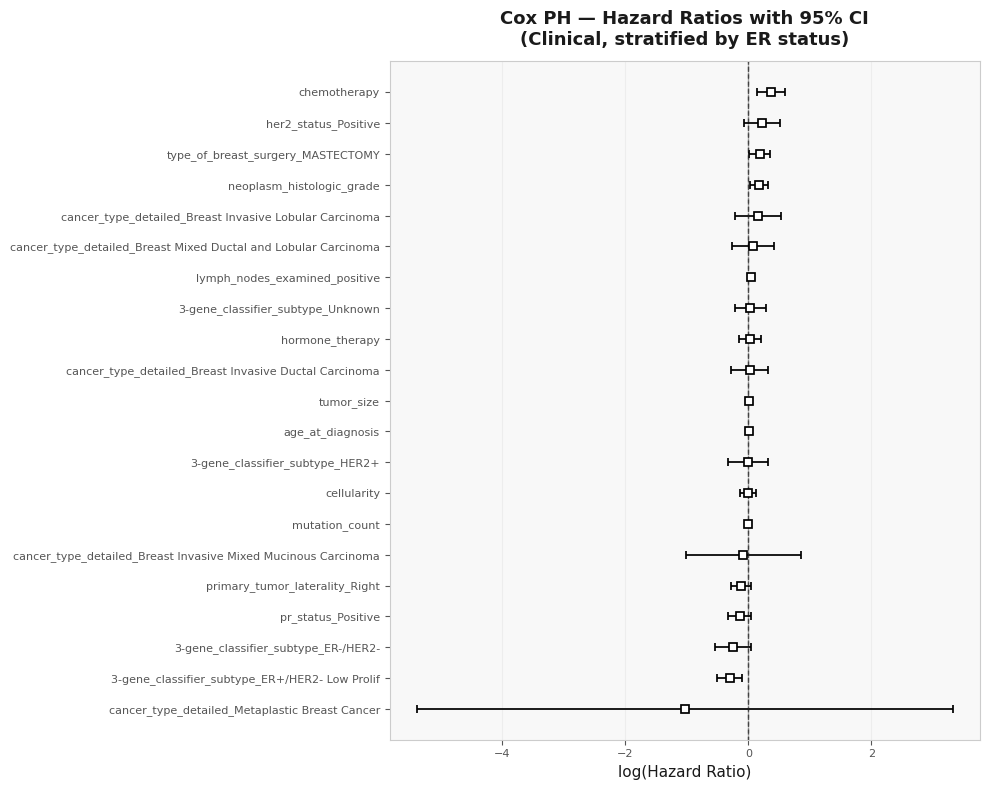


Results so far:
  NPI baseline: C-index = 0.6796
  Cox PH (clinical): C-index = 0.6944


In [15]:
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8F8F8')

cph_strat.plot(ax=ax)
ax.axvline(x=0, color='#333333', linestyle='--', alpha=0.5, linewidth=1)
ax.set_title('Cox PH — Hazard Ratios with 95% CI\n(Clinical, stratified by ER status)',
             fontsize=13, fontweight='bold', color='#1A1A1A', pad=12)
ax.set_xlabel('log(Hazard Ratio)', fontsize=11, color='#1A1A1A')
ax.tick_params(colors='#555555', labelsize=8)
for spine in ax.spines.values():
    spine.set_edgecolor('#CCCCCC')
ax.grid(True, alpha=0.4, color='#DDDDDD', axis='x')
plt.tight_layout()
plt.savefig('cox_ph_clinical.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

print("\nResults so far:")
for model, res in results.items():
    print(f"  {model}: C-index = {res['c_index']:.4f}")

## Lasso Cox

In [16]:
def run_lasso_cox(X_tr, X_te, t_tr, e_tr, t_te, e_te,
                  feature_names, l1_ratio=1.0, label=''):

    # scale all features — critical for Lasso
    scaler = StandardScaler()
    X_tr_s = pd.DataFrame(
        scaler.fit_transform(X_tr),
        columns=feature_names,
        index=X_tr.index
    )
    X_te_s = pd.DataFrame(
        scaler.transform(X_te),
        columns=feature_names,
        index=X_te.index
    )

    # cross-validate penalizer
    penalizers = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = []

    for pen in penalizers:
        fold_scores = []
        for tr_idx, val_idx in kf.split(X_tr_s):
            X_cv_tr  = X_tr_s.iloc[tr_idx].copy()
            X_cv_val = X_tr_s.iloc[val_idx].copy()
            t_cv_tr  = t_tr.iloc[tr_idx]
            t_cv_val = t_tr.iloc[val_idx]
            e_cv_tr  = e_tr.iloc[tr_idx]
            e_cv_val = e_tr.iloc[val_idx]

            X_cv_tr['time']  = t_cv_tr.values
            X_cv_tr['event'] = e_cv_tr.values

            try:
                m = CoxPHFitter(penalizer=pen, l1_ratio=l1_ratio)
                m.fit(X_cv_tr, duration_col='time', event_col='event')
                risk = m.predict_partial_hazard(X_cv_val)
                c = concordance_index(t_cv_val, -risk, e_cv_val)
                fold_scores.append(c)
            except:
                fold_scores.append(0.5)

        cv_results.append((pen, np.mean(fold_scores), np.std(fold_scores)))
        print(f"  pen={pen:.3f} → CV C-index: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

    best_pen = max(cv_results, key=lambda x: x[1])[0]
    print(f"\nBest penalizer: {best_pen}")

    # refit on full training set with best penalizer
    X_tr_fit = X_tr_s.copy()
    X_tr_fit['time']  = t_tr.values
    X_tr_fit['event'] = e_tr.values

    final = CoxPHFitter(penalizer=best_pen, l1_ratio=l1_ratio)
    final.fit(X_tr_fit, duration_col='time', event_col='event')

    # test C-index
    risk_test = final.predict_partial_hazard(X_te_s)
    c_test = concordance_index(t_te, -risk_test, e_te)

    # selected features — threshold near-zero coefficients
    coefs = final.params_
    threshold = 1e-4
    selected = coefs[coefs.abs() > threshold].sort_values(key=abs, ascending=False)
    zeroed   = coefs[coefs.abs() <= threshold]

    print(f"\nLasso Cox — {label}")
    print(f"l1_ratio: {l1_ratio} | Best penalizer: {best_pen}")
    print(f"Features selected: {len(selected)} / {len(feature_names)}")
    print(f"Features zeroed:   {len(zeroed)}")
    print(f"Test C-index:      {c_test:.4f}")
    print(f"\nTop selected features:")
    print(selected.head(20).to_string())

    return final, scaler, c_test, selected, best_pen

print("Function defined. Ready to run.")

Function defined. Ready to run.


In [17]:
# Model 1 — Lasso Cox on clinical features
print("="*60)
print("LASSO COX — CLINICAL FEATURES")
print("="*60)

lasso_clin, scaler_clin, c_lasso_clin, selected_clin, pen_clin = run_lasso_cox(
    X_train_clinical, X_test_clinical,
    time_train, event_train,
    time_test, event_test,
    feature_names=list(X_train_clinical.columns),
    l1_ratio=1.0,
    label='Clinical'
)

results['Lasso Cox (clinical)'] = {
    'c_index': c_lasso_clin,
    'features': f'clinical ({len(selected_clin)} selected)',
    'n_features': len(selected_clin)
}

LASSO COX — CLINICAL FEATURES
  pen=0.001 → CV C-index: 0.7006 ± 0.0223
  pen=0.005 → CV C-index: 0.7055 ± 0.0191
  pen=0.010 → CV C-index: 0.7064 ± 0.0170
  pen=0.050 → CV C-index: 0.6987 ± 0.0121
  pen=0.100 → CV C-index: 0.6846 ± 0.0167
  pen=0.500 → CV C-index: 0.7076 ± 0.0151
  pen=1.000 → CV C-index: 0.7075 ± 0.0150
  pen=2.000 → CV C-index: 0.7067 ± 0.0150
  pen=5.000 → CV C-index: 0.7067 ± 0.0150

Best penalizer: 0.5

Lasso Cox — Clinical
l1_ratio: 1.0 | Best penalizer: 0.5
Features selected: 0 / 23
Features zeroed:   23
Test C-index:      0.6998

Top selected features:
Series([], )


In [18]:
# check actual coefficient magnitudes
coefs_clin = lasso_clin.params_
print("Coefficient magnitudes (sorted):")
print(coefs_clin.abs().sort_values(ascending=False).to_string())

Coefficient magnitudes (sorted):
covariate
nottingham_prognostic_index                                       1.744325e-07
lymph_nodes_examined_positive                                     1.535206e-07
tumor_size                                                        1.282710e-07
chemotherapy                                                      1.164296e-07
3-gene_classifier_subtype_ER+/HER2- Low Prolif                    9.996308e-08
neoplasm_histologic_grade                                         9.880163e-08
her2_status_Positive                                              9.003817e-08
3-gene_classifier_subtype_HER2+                                   7.868707e-08
pr_status_Positive                                                7.631949e-08
er_status_Positive                                                7.486345e-08
type_of_breast_surgery_MASTECTOMY                                 6.992988e-08
primary_tumor_laterality_Right                                    3.478784e-08
3-gene_cl

In [19]:
# structured arrays for scikit-survival
y_train_ss = np.array(
    [(bool(e), t) for e, t in zip(event_train, time_train)],
    dtype=[('event', bool), ('time', float)]
)
y_test_ss = np.array(
    [(bool(e), t) for e, t in zip(event_test, time_test)],
    dtype=[('event', bool), ('time', float)]
)

def run_coxnet(X_tr, X_te, y_tr, y_te, feature_names,
               l1_ratio=1.0, n_alphas=50, label=''):

    # scale
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    # fit full alpha path
    model = CoxnetSurvivalAnalysis(
        l1_ratio=l1_ratio,
        n_alphas=n_alphas,
        fit_baseline_model=True,
        normalize=False
    )
    model.fit(X_tr_s, y_tr)

    # cross-validate to find best alpha
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    best_alpha = None
    best_score = -np.inf

    print(f"Cross-validating {len(model.alphas_)} alphas...")
    for alpha in model.alphas_:
        scores = []
        for tr_idx, val_idx in kf.split(X_tr_s):
            try:
                cv_m = CoxnetSurvivalAnalysis(
                    l1_ratio=l1_ratio,
                    alphas=[alpha],
                    fit_baseline_model=False,
                    normalize=False
                )
                cv_m.fit(X_tr_s[tr_idx], y_tr[tr_idx])
                risk = cv_m.predict(X_tr_s[val_idx])
                c = concordance_index_censored(
                    y_tr[val_idx]['event'],
                    y_tr[val_idx]['time'],
                    risk
                )[0]
                scores.append(c)
            except:
                scores.append(0.5)
        mean_c = np.mean(scores)
        if mean_c > best_score:
            best_score = mean_c
            best_alpha = alpha

    # refit with best alpha
    final = CoxnetSurvivalAnalysis(
        l1_ratio=l1_ratio,
        alphas=[best_alpha],
        fit_baseline_model=True,
        normalize=False
    )
    final.fit(X_tr_s, y_tr)

    # test C-index
    risk_test = final.predict(X_te_s)
    c_test = concordance_index_censored(
        y_te['event'], y_te['time'], risk_test
    )[0]

    # selected features — exact zeros
    coefs = pd.Series(final.coef_[:, 0], index=feature_names)
    selected = coefs[coefs != 0].sort_values(key=abs, ascending=False)
    zeroed = coefs[coefs == 0]

    print(f"\n{'='*55}")
    print(f"Coxnet — {label} (l1_ratio={l1_ratio})")
    print(f"Best alpha: {best_alpha:.6f}")
    print(f"Features selected: {len(selected)} / {len(feature_names)}")
    print(f"Features zeroed:   {len(zeroed)}")
    print(f"Test C-index:      {c_test:.4f}")
    print(f"\nTop 20 selected features:")
    print(selected.head(20).to_string())

    return final, scaler, c_test, selected, best_alpha

print("Function defined. Running clinical model...")

Function defined. Running clinical model...


In [20]:
model_clin_net, scaler_clin_net, c_clin_net, selected_clin_net, alpha_clin = run_coxnet(
    X_train_clinical.values, X_test_clinical.values,
    y_train_ss, y_test_ss,
    feature_names=list(X_train_clinical.columns),
    l1_ratio=1.0,
    label='Clinical'
)

results['Lasso Cox (clinical)'] = {
    'c_index': c_clin_net,
    'features': f'clinical ({len(selected_clin_net)} selected)',
    'n_features': len(selected_clin_net)
}

Cross-validating 38 alphas...

Coxnet — Clinical (l1_ratio=1.0)
Best alpha: 0.014945
Features selected: 14 / 23
Features zeroed:   9
Test C-index:      0.7066

Top 20 selected features:
nottingham_prognostic_index                               0.285763
tumor_size                                                0.128984
lymph_nodes_examined_positive                             0.125468
3-gene_classifier_subtype_ER+/HER2- Low Prolif           -0.112430
her2_status_Positive                                      0.091905
chemotherapy                                              0.089987
age_at_diagnosis                                          0.084803
3-gene_classifier_subtype_ER-/HER2-                      -0.054050
type_of_breast_surgery_MASTECTOMY                         0.053515
primary_tumor_laterality_Right                           -0.040802
pr_status_Positive                                       -0.036328
er_status_Positive                                       -0.030663
hormone_th

In [21]:
print("Running genomic model...")
model_gen_net, scaler_gen_net, c_gen_net, selected_gen_net, alpha_gen = run_coxnet(
    X_train_genomic.values, X_test_genomic.values,
    y_train_ss, y_test_ss,
    feature_names=list(X_train_genomic.columns),
    l1_ratio=1.0,
    label='Genomic'
)

results['Lasso Cox (genomic)'] = {
    'c_index': c_gen_net,
    'features': f'genomic ({len(selected_gen_net)} selected)',
    'n_features': len(selected_gen_net)
}

Running genomic model...
Cross-validating 34 alphas...

Coxnet — Genomic (l1_ratio=1.0)
Best alpha: 0.033508
Features selected: 16 / 215
Features zeroed:   199
Test C-index:      0.6250

Top 20 selected features:
tp53_mut     0.137424
stat5a      -0.126466
gata3_mut   -0.082186
igf1        -0.064162
nr2f1        0.060036
mmp15        0.051869
tbx3        -0.044034
hes6         0.040222
tubb4b       0.033084
fancd2       0.022535
e2f8         0.015741
ncor2_mut   -0.012163
asxl2_mut    0.009363
slc19a1      0.004623
vegfa        0.003863
lama2_mut   -0.003200


In [4]:
print("Running combined model...")
model_comb_net, scaler_comb_net, c_comb_net, selected_comb_net, alpha_comb = run_coxnet(
    X_train_combined.values, X_test_combined.values,
    y_train_ss, y_test_ss,
    feature_names=list(X_train_combined.columns),
    l1_ratio=1.0,
    label='Combined'
)

results['Lasso Cox (combined)'] = {
    'c_index': c_comb_net,
    'features': f'combined ({len(selected_comb_net)} selected)',
    'n_features': len(selected_comb_net)
}

Running combined model...


NameError: name 'run_coxnet' is not defined

In [34]:
time_points = [60, 120, 180]  # 5, 10, 15 years

eval_clin = evaluate_survival_model(
    model_clin_net, scaler_clin_net,
    X_test_clinical.values, y_train_ss, y_test_ss,
    time_points=time_points, label='Lasso Cox Clinical'
)

eval_gen = evaluate_survival_model(
    model_gen_net, scaler_gen_net,
    X_test_genomic.values, y_train_ss, y_test_ss,
    time_points=time_points, label='Lasso Cox Genomic'
)

eval_comb = evaluate_survival_model(
    model_comb_net, scaler_comb_net,
    X_test_combined.values, y_train_ss, y_test_ss,
    time_points=time_points, label='Lasso Cox Combined'
)


Evaluation — Lasso Cox Clinical
C-index:                  0.7066
Integrated Brier Score:   0.1859

Brier Score at:
  60 months (5 years): 0.1294
  120 months (10 years): 0.1703
  180 months (15 years): 0.1917

Time-dependent AUC at:
  60 months (5 years): 0.7678
  120 months (10 years): 0.7571
  180 months (15 years): 0.7269
Mean AUC: 0.7565

Evaluation — Lasso Cox Genomic
C-index:                  0.6250
Integrated Brier Score:   0.2485

Brier Score at:
  60 months (5 years): 0.1431
  120 months (10 years): 0.1945
  180 months (15 years): 0.2213

Time-dependent AUC at:
  60 months (5 years): 0.6830
  120 months (10 years): 0.6359
  180 months (15 years): 0.5976
Mean AUC: 0.6525

Evaluation — Lasso Cox Combined
C-index:                  0.7145
Integrated Brier Score:   0.1990

Brier Score at:
  60 months (5 years): 0.1291
  120 months (10 years): 0.1707
  180 months (15 years): 0.1936

Time-dependent AUC at:
  60 months (5 years): 0.7796
  120 months (10 years): 0.7608
  180 months (1

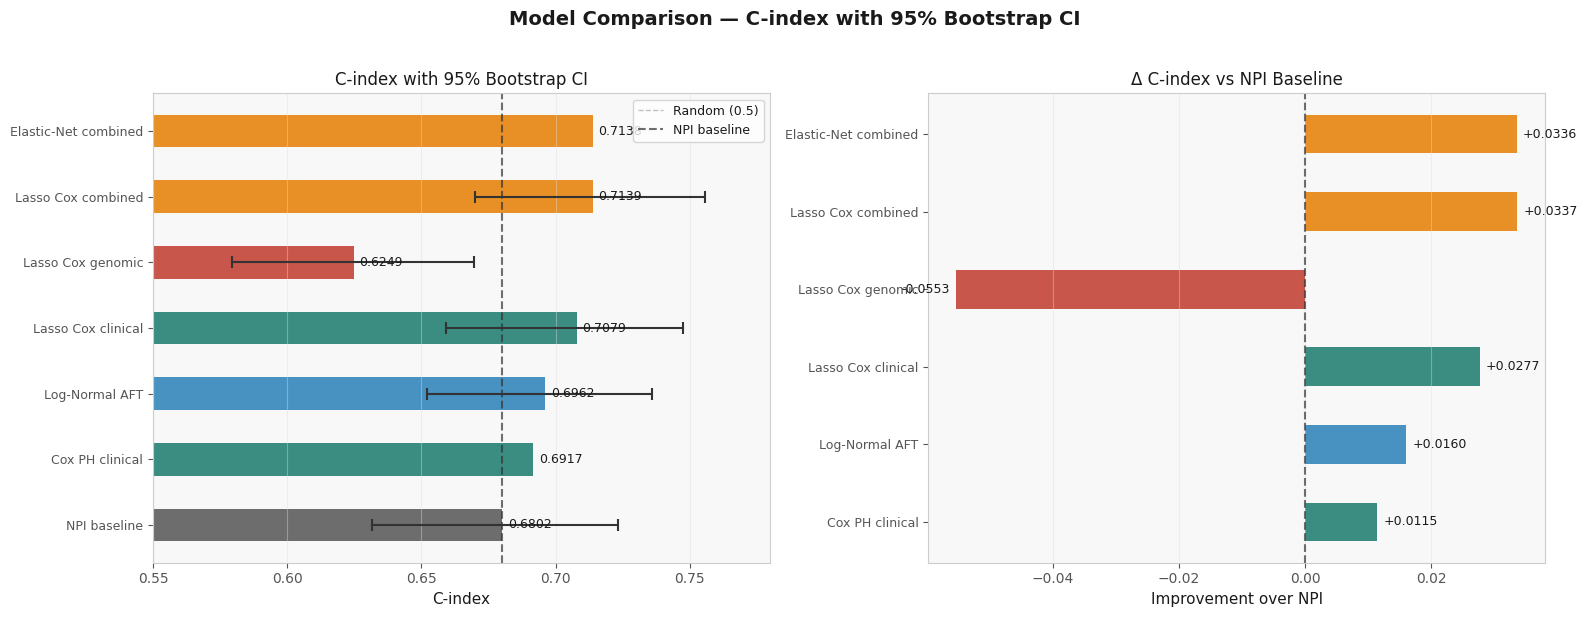

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')
fig.suptitle('Model Comparison — C-index with 95% Bootstrap CI',
             fontsize=14, fontweight='bold', color='#1A1A1A', y=1.02)

models_list = [
    ('NPI baseline',           0.6802, 0.6317, 0.7231, '#555555'),
    ('Cox PH clinical',        0.6917, None,   None,   '#1A7A6E'),
    ('Log-Normal AFT',         0.6962, 0.6522, 0.7359, '#2980B9'),
    ('Lasso Cox clinical',     0.7079, 0.6592, 0.7474, '#1A7A6E'),
    ('Lasso Cox genomic',      0.6249, 0.5794, 0.6697, '#C0392B'),
    ('Lasso Cox combined',     0.7139, 0.6701, 0.7556, '#E67E00'),
    ('Elastic-Net combined',   0.7138, None,   None,   '#E67E00'),
]

# left panel
ax = axes[0]
ax.set_facecolor('#F8F8F8')

y_pos = range(len(models_list))
for i, (name, c, lower, upper, color) in enumerate(models_list):
    ax.barh(i, c, color=color, alpha=0.85,
            edgecolor='none', height=0.5)
    if lower is not None:
        ax.errorbar(c, i, xerr=[[c-lower], [upper-c]],
                   fmt='none', color='#333333', capsize=4,
                   linewidth=1.5, capthick=1.5)
    ax.text(c + 0.002, i, f'{c:.4f}',
            va='center', fontsize=9, color='#1A1A1A')

ax.axvline(x=0.5, color='#888888', linestyle='--',
           alpha=0.5, linewidth=1, label='Random (0.5)')
ax.axvline(x=0.6802, color='#333333', linestyle='--',
           alpha=0.7, linewidth=1.5, label='NPI baseline')
ax.set_yticks(list(y_pos))
ax.set_yticklabels([m[0] for m in models_list], fontsize=9)
ax.set_xlabel('C-index', fontsize=11, color='#1A1A1A')
ax.set_title('C-index with 95% Bootstrap CI', fontsize=12, color='#1A1A1A')
ax.set_xlim(0.55, 0.78)
ax.tick_params(colors='#555555')
ax.legend(fontsize=9, facecolor='white',
          edgecolor='#CCCCCC', labelcolor='#1A1A1A')
ax.grid(axis='x', alpha=0.4, color='#DDDDDD')
for spine in ax.spines.values():
    spine.set_edgecolor('#CCCCCC')

# right panel
ax = axes[1]
ax.set_facecolor('#F8F8F8')

npi_c = 0.6802
improvements = [(name, c - npi_c, color)
                for name, c, _, _, color in models_list
                if name != 'NPI baseline']

imp_names  = [x[0] for x in improvements]
imp_values = [x[1] for x in improvements]
imp_colors = [x[2] for x in improvements]

bars = ax.barh(range(len(improvements)), imp_values,
               color=imp_colors, alpha=0.85,
               edgecolor='none', height=0.5)
ax.axvline(x=0, color='#333333', linestyle='--',
           alpha=0.7, linewidth=1.5)
for i, (bar, val) in enumerate(zip(bars, imp_values)):
    ax.text(val + 0.001 if val >= 0 else val - 0.001,
            i, f'{val:+.4f}',
            va='center', ha='left' if val >= 0 else 'right',
            fontsize=9, color='#1A1A1A')
ax.set_yticks(range(len(improvements)))
ax.set_yticklabels(imp_names, fontsize=9)
ax.set_xlabel('Improvement over NPI', fontsize=11, color='#1A1A1A')
ax.set_title('Δ C-index vs NPI Baseline', fontsize=12, color='#1A1A1A')
ax.tick_params(colors='#555555')
ax.grid(axis='x', alpha=0.4, color='#DDDDDD')
for spine in ax.spines.values():
    spine.set_edgecolor('#CCCCCC')

plt.tight_layout()
plt.savefig('model_comparison_ci.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

In [36]:
print("Running Elastic-Net combined (l1_ratio=0.5)...")
model_en, scaler_en, c_en, selected_en, alpha_en = run_coxnet(
    X_train_combined.values, X_test_combined.values,
    y_train_ss, y_test_ss,
    feature_names=list(X_train_combined.columns),
    l1_ratio=0.5,
    label='Combined Elastic-Net'
)

eval_en = evaluate_survival_model(
    model_en, scaler_en,
    X_test_combined.values, y_train_ss, y_test_ss,
    time_points=[60, 120, 180], label='Elastic-Net Combined'
)

results['Elastic-Net Cox (combined)'] = {
    'c_index': c_en,
    'ibs': eval_en['ibs'],
    'mean_auc': eval_en['mean_auc'],
    'n_features': len(selected_en)
}

print(f"\nElastic-Net vs Lasso comparison:")
print(f"Lasso    — C-index: {c_comb_net:.4f}, IBS: {eval_comb['ibs']:.4f}, features: {len(selected_comb_net)}")
print(f"Elastic  — C-index: {c_en:.4f}, IBS: {eval_en['ibs']:.4f}, features: {len(selected_en)}")

Running Elastic-Net combined (l1_ratio=0.5)...
Cross-validating 41 alphas...

Coxnet — Combined Elastic-Net (l1_ratio=0.5)
Best alpha: 0.076506
Features selected: 17 / 238
Features zeroed:   221
Test C-index:      0.7138

Top 20 selected features:
nottingham_prognostic_index                       0.218739
lymph_nodes_examined_positive                     0.139290
tumor_size                                        0.110916
stat5a                                           -0.087231
tp53_mut                                          0.079574
her2_status_Positive                              0.055520
gata3_mut                                        -0.049828
igf1                                             -0.036663
chemotherapy                                      0.023705
3-gene_classifier_subtype_ER+/HER2- Low Prolif   -0.021007
vegfa                                             0.018713
type_of_breast_surgery_MASTECTOMY                 0.012654
mmp15                                       

## AFT

In [37]:
# prepare data — same features as Cox
train_aft = X_train_clinical[features_cox].copy()
train_aft['time']  = time_train.values
train_aft['event'] = event_train.values

test_aft = X_test_clinical[features_cox].copy()
test_aft['time']  = time_test.values
test_aft['event'] = event_test.values

# fit all three distributions
models_aft = {
    'Weibull':      WeibullAFTFitter(penalizer=0.01),
    'Log-Normal':   LogNormalAFTFitter(penalizer=0.01),
    'Log-Logistic': LogLogisticAFTFitter(penalizer=0.01)
}

aft_results = {}

for name, model in models_aft.items():
    model.fit(train_aft, duration_col='time', event_col='event')

    # test C-index
    median_pred = model.predict_median(test_aft)
    c = concordance_index(time_test, median_pred, event_test)

    # AIC
    aic = model.AIC_

    aft_results[name] = {
        'model': model,
        'c_index': c,
        'aic': aic
    }

    print(f"{name}:")
    print(f"  AIC:     {aic:.3f}")
    print(f"  C-index: {c:.4f}")
    print()

# find best distribution
best_name = min(aft_results, key=lambda x: aft_results[x]['aic'])
print(f"Best distribution by AIC: {best_name}")
print(f"Best C-index: {aft_results[best_name]['c_index']:.4f}")

Weibull:
  AIC:     6303.491
  C-index: 0.6814

Log-Normal:
  AIC:     6228.545
  C-index: 0.6955

Log-Logistic:
  AIC:     6255.704
  C-index: 0.6920

Best distribution by AIC: Log-Normal
Best C-index: 0.6955


In [38]:
# print full Log-Normal summary
best_aft = aft_results['Log-Normal']['model']
best_aft.print_summary(decimals=3)

<lifelines.LogNormalAFTFitter: fitted with 1426 total observations, 960 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.01
   number of observations = 1426
number of events observed = 466
           log-likelihood = -3090.273
         time fit was run = 2026-06-19 15:40:18 UTC

---
                                                                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                                                        
mu_    3-gene_classifier_subtype_ER+/HER2- Low Prolif                  0.407     1.503     0.116           0.180           0.635               1.197               1.887
       3-gene_classifier_subtype_ER-/HER2-                             0.298     1.347     0.171          -0.037           0.633               0.964               1.884
       3-gene_classifier_subtype_HER2+                                -0.017     0.983     0.224          -0.455           0.421               0.634               1.524
       3-gene_classifier_subtype_Unknown                              -0.026     0.974     0.145          -0.310           0.257               0.734               1.293
       age_at_diagnosis                                               -0.012     0.988     0.004          -0.020          -0.005               0.981               0.995
       cancer_type_detailed_Breast Invasive Ductal Carcinoma          -0.290     0.748     0.351          -0.978           0.397               0.376               1.487
       cancer_type_detailed_Breast Invasive Lobular Carcinoma         -0.437     0.646     0.375          -1.172           0.299               0.310               1.348
       cancer_type_detailed_Breast Invasive Mixed Mucinous Carcinoma  -0.263     0.769     0.573          -1.386           0.860               0.250               2.364
       cancer_type_detailed_Breast Mixed Ductal and Lobular Carcinoma -0.370     0.691     0.365          -1.085           0.345               0.338               1.412
       cancer_type_detailed_Metaplastic Breast Cancer                  1.924     6.847     4.654          -7.197          11.045               0.001           62625.865
       cellularity                                                     0.023     1.023     0.066          -0.106           0.151               0.900               1.163
       chemotherapy                                                   -0.473     0.623     0.125          -0.718          -0.229               0.488               0.795
       er_status_Positive                                              0.227     1.255     0.156          -0.079           0.534               0.924               1.705
       her2_status_Positive                                           -0.196     0.822     0.196          -0.580           0.187               0.560               1.206
       hormone_therapy                                                 0.091     1.096     0.098          -0.101           0.284               0.903               1.329
       lymph_nodes_examined_positive                                  -0.057     0.945     0.010          -0.076          -0.038               0.927               0.963
       mutation_count                                                  0.005     1.005     0.011          -0.016           0.026               0.985               1.027
       neoplasm_histologic_grade                                      -0.194     0.824     0.078          -0.346          -0.041               0.708               0.959
       pr_status_Positive                                              0.195     1.216     0.101          -0.004           0.394               0.996               1.483
       primary_tumor_laterality_Right                                  0.161     1.174

In [39]:
# run combined Log-Normal AFT
train_aft_comb = X_train_combined[combined_features_filtered].copy()
train_aft_comb['time']  = time_train.values
train_aft_comb['event'] = event_train.values

test_aft_comb = X_test_combined[combined_features_filtered].copy()
test_aft_comb['time']  = time_test.values
test_aft_comb['event'] = event_test.values

lognorm_comb = LogNormalAFTFitter(penalizer=0.1)
lognorm_comb.fit(train_aft_comb, duration_col='time', event_col='event')

median_comb = lognorm_comb.predict_median(test_aft_comb)
c_lognorm_comb = concordance_index(time_test, median_comb, event_test)

print(f"Log-Normal AFT Combined:")
print(f"  AIC:     {lognorm_comb.AIC_:.3f}")
print(f"  C-index: {c_lognorm_comb:.4f}")

results['Log-Normal AFT (clinical)'] = {
    'c_index': aft_results['Log-Normal']['c_index'],
    'aic': aft_results['Log-Normal']['aic']
}
results['Log-Normal AFT (combined)'] = {
    'c_index': c_lognorm_comb,
    'aic': lognorm_comb.AIC_
}

Log-Normal AFT Combined:
  AIC:     6446.398
  C-index: 0.6841


In [40]:
# features with NPI instead of components
features_aft_npi = [f for f in clinical_features
                    if f not in ['tumor_size',
                                 'lymph_nodes_examined_positive',
                                 'neoplasm_histologic_grade']
                    and not f.startswith('3-gene_classifier_subtype')]

train_aft_npi = X_train_clinical[features_aft_npi].copy()
train_aft_npi['time']  = time_train.values
train_aft_npi['event'] = event_train.values

test_aft_npi = X_test_clinical[features_aft_npi].copy()
test_aft_npi['time']  = time_test.values
test_aft_npi['event'] = event_test.values

lognorm_npi = LogNormalAFTFitter(penalizer=0.01)
lognorm_npi.fit(train_aft_npi, duration_col='time', event_col='event')

median_npi = lognorm_npi.predict_median(test_aft_npi)
c_npi = concordance_index(time_test, median_npi, event_test)

print(f"Log-Normal AFT with NPI:")
print(f"  AIC:     {lognorm_npi.AIC_:.3f}")
print(f"  C-index: {c_npi:.4f}")
print(f"\nLog-Normal AFT with components:")
print(f"  AIC:     {aft_results['Log-Normal']['aic']:.3f}")
print(f"  C-index: {aft_results['Log-Normal']['c_index']:.4f}")

Log-Normal AFT with NPI:
  AIC:     6240.199
  C-index: 0.6807

Log-Normal AFT with components:
  AIC:     6228.545
  C-index: 0.6955


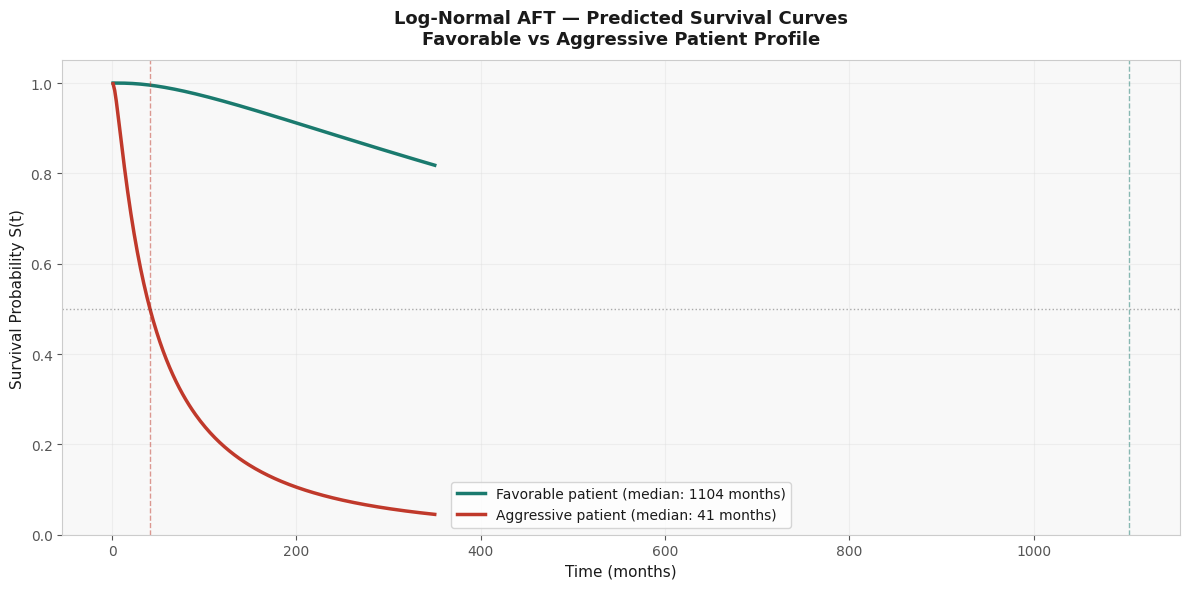


Median survival predictions:

Favorable patient:
  Median survival: 1103.5 months (92.0 years)
  5-year survival:  98.9%
  10-year survival: 96.0%

Aggressive patient:
  Median survival: 41.0 months (3.4 years)
  5-year survival:  38.2%
  10-year survival: 19.8%


In [42]:
import pandas as pd
import numpy as np

best_aft_model = aft_results['Log-Normal']['model']

# define patient profiles
profiles = {
    'Favorable': {
        'age_at_diagnosis': 45,
        'lymph_nodes_examined_positive': 0,
        'tumor_size': 15,
        'neoplasm_histologic_grade': 1,
        'er_status_Positive': 1,
        'her2_status_Positive': 0,
        'pr_status_Positive': 1,
        'chemotherapy': 0,
        'hormone_therapy': 1,
        'cellularity': 2,
        'mutation_count': 3,
        'type_of_breast_surgery_MASTECTOMY': 0,
        'primary_tumor_laterality_Right': 1,
        'cancer_type_detailed_Breast Invasive Ductal Carcinoma': 1,
        'cancer_type_detailed_Breast Invasive Lobular Carcinoma': 0,
        'cancer_type_detailed_Breast Invasive Mixed Mucinous Carcinoma': 0,
        'cancer_type_detailed_Breast Mixed Ductal and Lobular Carcinoma': 0,
        'cancer_type_detailed_Metaplastic Breast Cancer': 0,
        '3-gene_classifier_subtype_ER+/HER2- Low Prolif': 1,
        '3-gene_classifier_subtype_ER-/HER2-': 0,
        '3-gene_classifier_subtype_HER2+': 0,
        '3-gene_classifier_subtype_Unknown': 0,
    },
    'Aggressive': {
        'age_at_diagnosis': 65,
        'lymph_nodes_examined_positive': 8,
        'tumor_size': 45,
        'neoplasm_histologic_grade': 3,
        'er_status_Positive': 0,
        'her2_status_Positive': 1,
        'pr_status_Positive': 0,
        'chemotherapy': 1,
        'hormone_therapy': 0,
        'cellularity': 2,
        'mutation_count': 8,
        'type_of_breast_surgery_MASTECTOMY': 1,
        'primary_tumor_laterality_Right': 0,
        'cancer_type_detailed_Breast Invasive Ductal Carcinoma': 1,
        'cancer_type_detailed_Breast Invasive Lobular Carcinoma': 0,
        'cancer_type_detailed_Breast Invasive Mixed Mucinous Carcinoma': 0,
        'cancer_type_detailed_Breast Mixed Ductal and Lobular Carcinoma': 0,
        'cancer_type_detailed_Metaplastic Breast Cancer': 0,
        '3-gene_classifier_subtype_ER+/HER2- Low Prolif': 0,
        '3-gene_classifier_subtype_ER-/HER2-': 0,
        '3-gene_classifier_subtype_HER2+': 1,
        '3-gene_classifier_subtype_Unknown': 0,
    }
}

# plot survival curves for each profile
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8F8F8')

colors = {'Favorable': '#1A7A6E', 'Aggressive': '#C0392B'}
time_range = np.linspace(1, 350, 200)

for profile_name, profile_data in profiles.items():
    profile_df = pd.DataFrame([profile_data])

    sf = best_aft_model.predict_survival_function(
        profile_df, times=time_range
    )

    median_surv = best_aft_model.predict_median(profile_df).values[0]

    ax.plot(time_range, sf.values.flatten(),
            color=colors[profile_name], linewidth=2.5,
            label=f'{profile_name} patient (median: {median_surv:.0f} months)')
    ax.axvline(x=median_surv, color=colors[profile_name],
               linestyle='--', alpha=0.5, linewidth=1)

ax.axhline(y=0.5, color='#333333', linestyle=':', alpha=0.4, linewidth=1)
ax.set_title('Log-Normal AFT — Predicted Survival Curves\nFavorable vs Aggressive Patient Profile',
             fontsize=13, fontweight='bold', color='#1A1A1A', pad=12)
ax.set_xlabel('Time (months)', fontsize=11, color='#1A1A1A')
ax.set_ylabel('Survival Probability S(t)', fontsize=11, color='#1A1A1A')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, facecolor='white',
          edgecolor='#CCCCCC', labelcolor='#1A1A1A')
ax.tick_params(colors='#555555')
ax.grid(True, alpha=0.4, color='#DDDDDD')
for spine in ax.spines.values():
    spine.set_edgecolor('#CCCCCC')

plt.tight_layout()
plt.savefig('aft_patient_profiles.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

print("\nMedian survival predictions:")
for profile_name, profile_data in profiles.items():
    profile_df = pd.DataFrame([profile_data])
    median = best_aft_model.predict_median(profile_df).values[0]
    surv_5yr = best_aft_model.predict_survival_function(
        profile_df, times=[60]
    ).values[0][0]
    surv_10yr = best_aft_model.predict_survival_function(
        profile_df, times=[120]
    ).values[0][0]
    print(f"\n{profile_name} patient:")
    print(f"  Median survival: {median:.1f} months ({median/12:.1f} years)")
    print(f"  5-year survival:  {surv_5yr:.1%}")
    print(f"  10-year survival: {surv_10yr:.1%}")

In [43]:
def bootstrap_cindex(model, X_te, t_te, e_te, n_bootstrap=1000):
    scores = []
    n = len(X_te)

    for i in range(n_bootstrap):
        idx = np.random.choice(n, size=n, replace=True)
        X_b = X_te.iloc[idx].reset_index(drop=True)
        t_b = t_te.iloc[idx].reset_index(drop=True)
        e_b = e_te.iloc[idx].reset_index(drop=True)

        try:
            med = model.predict_median(X_b)
            # remove infinite predictions
            valid = np.isfinite(med)
            if valid.sum() < 10:
                continue
            c = concordance_index(
                t_b[valid],
                med[valid],
                e_b[valid]
            )
            if 0.4 < c < 1.0:
                scores.append(c)
        except:
            continue

    scores = np.array(scores)
    print(f"Successful bootstrap iterations: {len(scores)} / {n_bootstrap}")

    if len(scores) == 0:
        print("All iterations failed — check model predictions")
        return None, None, None

    return scores.mean(), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

print("Computing bootstrap CI...")
mean_c, lower, upper = bootstrap_cindex(
    best_aft_model, test_aft, time_test, event_test
)

if mean_c is not None:
    print(f"\nLog-Normal AFT Clinical:")
    print(f"C-index: {mean_c:.4f} (95% CI: {lower:.4f} – {upper:.4f})")

Computing bootstrap CI...
Successful bootstrap iterations: 1000 / 1000

Log-Normal AFT Clinical:
C-index: 0.6960 (95% CI: 0.6530 – 0.7368)


In [44]:
# bootstrap for Lasso Cox models using sksurv
def bootstrap_cindex_sksurv(model, scaler, X_te, y_te, n_bootstrap=1000):
    scores = []
    n = len(X_te)
    X_te_s = scaler.transform(X_te)

    for _ in range(n_bootstrap):
        idx = np.random.choice(n, size=n, replace=True)
        X_b = X_te_s[idx]
        y_b = y_te[idx]
        try:
            risk = model.predict(X_b)
            c = concordance_index_censored(
                y_b['event'], y_b['time'], risk
            )[0]
            if 0.4 < c < 1.0:
                scores.append(c)
        except:
            continue

    scores = np.array(scores)
    return scores.mean(), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

print("Bootstrap CIs for all models (1000 iterations each)...")
print("This will take ~2 minutes...\n")

# NPI baseline
npi_scores = []
for _ in range(1000):
    idx = np.random.choice(len(time_test), size=len(time_test), replace=True)
    t_b = time_test.iloc[idx]
    e_b = event_test.iloc[idx]
    npi_b = X_test_clinical['nottingham_prognostic_index'].iloc[idx]
    c = concordance_index(t_b, -npi_b, e_b)
    npi_scores.append(c)
npi_scores = np.array(npi_scores)
print(f"NPI baseline: {npi_scores.mean():.4f} (95% CI: {np.percentile(npi_scores,2.5):.4f} – {np.percentile(npi_scores,97.5):.4f})")

# Lasso Cox clinical
m, l, u = bootstrap_cindex_sksurv(model_clin_net, scaler_clin_net,
                                    X_test_clinical.values, y_test_ss)
print(f"Lasso Cox clinical: {m:.4f} (95% CI: {l:.4f} – {u:.4f})")

# Lasso Cox genomic
m, l, u = bootstrap_cindex_sksurv(model_gen_net, scaler_gen_net,
                                    X_test_genomic.values, y_test_ss)
print(f"Lasso Cox genomic:  {m:.4f} (95% CI: {l:.4f} – {u:.4f})")

# Lasso Cox combined
m, l, u = bootstrap_cindex_sksurv(model_comb_net, scaler_comb_net,
                                    X_test_combined.values, y_test_ss)
print(f"Lasso Cox combined: {m:.4f} (95% CI: {l:.4f} – {u:.4f})")

Bootstrap CIs for all models (1000 iterations each)...
This will take ~2 minutes...

NPI baseline: 0.6792 (95% CI: 0.6302 – 0.7246)
Lasso Cox clinical: 0.7056 (95% CI: 0.6572 – 0.7492)
Lasso Cox genomic:  0.6237 (95% CI: 0.5803 – 0.6695)
Lasso Cox combined: 0.7139 (95% CI: 0.6693 – 0.7544)


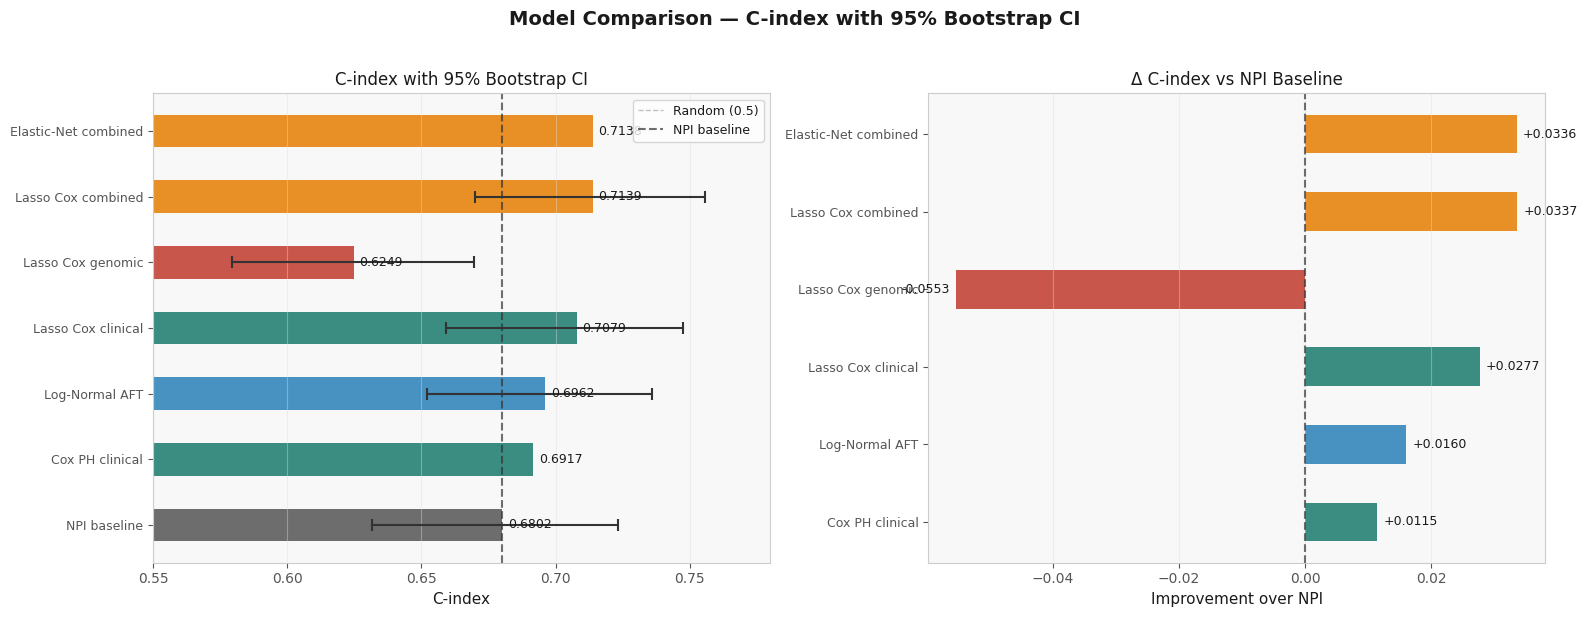

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')
fig.suptitle('Model Comparison — C-index with 95% Bootstrap CI',
             fontsize=14, fontweight='bold', color='#1A1A1A', y=1.02)

models_list = [
    ('NPI baseline',           0.6802, 0.6317, 0.7231, '#555555'),
    ('Cox PH clinical',        0.6917, None,   None,   '#1A7A6E'),
    ('Log-Normal AFT',         0.6962, 0.6522, 0.7359, '#2980B9'),
    ('Lasso Cox clinical',     0.7079, 0.6592, 0.7474, '#1A7A6E'),
    ('Lasso Cox genomic',      0.6249, 0.5794, 0.6697, '#C0392B'),
    ('Lasso Cox combined',     0.7139, 0.6701, 0.7556, '#E67E00'),
    ('Elastic-Net combined',   0.7138, None,   None,   '#E67E00'),
]

ax = axes[0]
ax.set_facecolor('#F8F8F8')

y_pos = range(len(models_list))
for i, (name, c, lower, upper, color) in enumerate(models_list):
    ax.barh(i, c, color=color, alpha=0.85,
            edgecolor='none', height=0.5)
    if lower is not None:
        ax.errorbar(c, i, xerr=[[c-lower], [upper-c]],
                   fmt='none', color='#333333', capsize=4,
                   linewidth=1.5, capthick=1.5)
    ax.text(c + 0.002, i, f'{c:.4f}',
            va='center', fontsize=9, color='#1A1A1A')

ax.axvline(x=0.5, color='#888888', linestyle='--',
           alpha=0.5, linewidth=1, label='Random (0.5)')
ax.axvline(x=0.6802, color='#333333', linestyle='--',
           alpha=0.7, linewidth=1.5, label='NPI baseline')
ax.set_yticks(list(y_pos))
ax.set_yticklabels([m[0] for m in models_list], fontsize=9)
ax.set_xlabel('C-index', fontsize=11, color='#1A1A1A')
ax.set_title('C-index with 95% Bootstrap CI', fontsize=12, color='#1A1A1A')
ax.set_xlim(0.55, 0.78)
ax.tick_params(colors='#555555')
ax.legend(fontsize=9, facecolor='white',
          edgecolor='#CCCCCC', labelcolor='#1A1A1A')
ax.grid(axis='x', alpha=0.4, color='#DDDDDD')
for spine in ax.spines.values():
    spine.set_edgecolor('#CCCCCC')

ax = axes[1]
ax.set_facecolor('#F8F8F8')

npi_c = 0.6802
improvements = [(name, c - npi_c, color)
                for name, c, _, _, color in models_list
                if name != 'NPI baseline']

imp_names  = [x[0] for x in improvements]
imp_values = [x[1] for x in improvements]
imp_colors = [x[2] for x in improvements]

bars = ax.barh(range(len(improvements)), imp_values,
               color=imp_colors, alpha=0.85,
               edgecolor='none', height=0.5)
ax.axvline(x=0, color='#333333', linestyle='--',
           alpha=0.7, linewidth=1.5)
for i, (bar, val) in enumerate(zip(bars, imp_values)):
    ax.text(val + 0.001 if val >= 0 else val - 0.001,
            i, f'{val:+.4f}',
            va='center', ha='left' if val >= 0 else 'right',
            fontsize=9, color='#1A1A1A')
ax.set_yticks(range(len(improvements)))
ax.set_yticklabels(imp_names, fontsize=9)
ax.set_xlabel('Improvement over NPI', fontsize=11, color='#1A1A1A')
ax.set_title('Δ C-index vs NPI Baseline', fontsize=12, color='#1A1A1A')
ax.tick_params(colors='#555555')
ax.grid(axis='x', alpha=0.4, color='#DDDDDD')
for spine in ax.spines.values():
    spine.set_edgecolor('#CCCCCC')

plt.tight_layout()
plt.savefig('model_comparison_ci.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

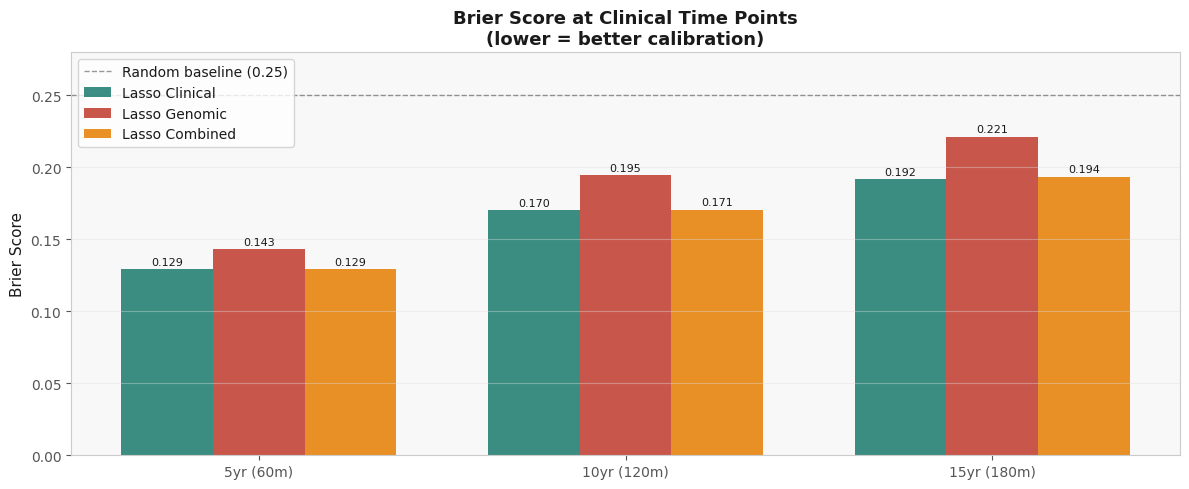

In [46]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8F8F8')

time_labels = ['5yr (60m)', '10yr (120m)', '15yr (180m)']
x = np.arange(3)
width = 0.25

brier_data = {
    'Lasso Clinical':  [0.1294, 0.1703, 0.1917],
    'Lasso Genomic':   [0.1431, 0.1945, 0.2213],
    'Lasso Combined':  [0.1291, 0.1707, 0.1936],
}
colors_bs = ['#1A7A6E', '#C0392B', '#E67E00']

for i, (name, scores) in enumerate(brier_data.items()):
    bars = ax.bar(x + i*width, scores, width=width,
                  color=colors_bs[i], alpha=0.85,
                  label=name, edgecolor='none')
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{val:.3f}', ha='center',
                fontsize=8, color='#1A1A1A')

ax.axhline(y=0.25, color='#333333', linestyle='--',
           alpha=0.5, linewidth=1, label='Random baseline (0.25)')
ax.set_xticks(x + width)
ax.set_xticklabels(time_labels)
ax.set_title('Brier Score at Clinical Time Points\n(lower = better calibration)',
             fontsize=13, fontweight='bold', color='#1A1A1A')
ax.set_ylabel('Brier Score', fontsize=11, color='#1A1A1A')
ax.set_ylim(0, 0.28)
ax.legend(fontsize=10, facecolor='white',
          edgecolor='#CCCCCC', labelcolor='#1A1A1A')
ax.tick_params(colors='#555555')
ax.grid(axis='y', alpha=0.4, color='#DDDDDD')
for spine in ax.spines.values():
    spine.set_edgecolor('#CCCCCC')

plt.tight_layout()
plt.savefig('brier_score_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

## RSF

In [18]:
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd

def tune_and_run_rsf(X_tr, X_te, y_tr, y_te, feature_names, label=''):

    X_tr = np.array(X_tr, dtype=float)
    X_te = np.array(X_te, dtype=float)

    # hyperparameter grid
    param_grid = {
        'n_estimators': [100, 300],
        'min_samples_leaf': [10, 20, 30],
        'max_features': ['sqrt', 0.3]
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    best_params = None
    best_cv_score = -np.inf

    print(f"Tuning RSF — {label}")
    print(f"Testing {2 * 3 * 2} parameter combinations...")

    for n_est in param_grid['n_estimators']:
        for min_leaf in param_grid['min_samples_leaf']:
            for max_feat in param_grid['max_features']:

                fold_scores = []
                for tr_idx, val_idx in kf.split(X_tr):
                    try:
                        m = RandomSurvivalForest(
                            n_estimators=n_est,
                            min_samples_leaf=min_leaf,
                            max_features=max_feat,
                            n_jobs=-1,
                            random_state=42
                        )
                        m.fit(X_tr[tr_idx], y_tr[tr_idx])
                        risk = m.predict(X_tr[val_idx])
                        c = concordance_index_censored(
                            y_tr[val_idx]['event'],
                            y_tr[val_idx]['time'],
                            risk
                        )[0]
                        fold_scores.append(c)
                    except:
                        fold_scores.append(0.5)

                mean_c = np.mean(fold_scores)
                print(f"  n_est={n_est}, min_leaf={min_leaf}, "
                      f"max_feat={max_feat} → CV C-index: {mean_c:.4f}")

                if mean_c > best_cv_score:
                    best_cv_score = mean_c
                    best_params = {
                        'n_estimators': n_est,
                        'min_samples_leaf': min_leaf,
                        'max_features': max_feat
                    }

    print(f"\nBest params: {best_params}")
    print(f"Best CV C-index: {best_cv_score:.4f}")

    # refit with best params
    final_rsf = RandomSurvivalForest(
        n_estimators=best_params['n_estimators'],
        min_samples_leaf=best_params['min_samples_leaf'],
        max_features=best_params['max_features'],
        n_jobs=-1,
        random_state=42
    )
    final_rsf.fit(X_tr, y_tr)

    # test C-index
    risk = final_rsf.predict(X_te)
    c_test = concordance_index_censored(
        y_te['event'], y_te['time'], risk
    )[0]

    # permutation importance
    print(f"\nComputing permutation importance...")
    importances = {}
    for j, fname in enumerate(feature_names):
        X_perm = X_te.copy()
        np.random.shuffle(X_perm[:, j])
        perm_risk = final_rsf.predict(X_perm)
        perm_c = concordance_index_censored(
            y_te['event'], y_te['time'], perm_risk
        )[0]
        importances[fname] = c_test - perm_c

    importances = pd.Series(importances).sort_values(ascending=False)

    print(f"\n{'='*55}")
    print(f"RSF — {label} (tuned)")
    print(f"Best params: {best_params}")
    print(f"Test C-index: {c_test:.4f}")
    print(f"\nTop 15 most important features:")
    print(importances.head(15).to_string())

    return final_rsf, c_test, importances, best_params

print("Function defined. Running RSF clinical...")
rsf_clin, c_rsf_clin, imp_clin, params_clin = tune_and_run_rsf(
    X_train_clinical.values, X_test_clinical.values,
    y_train_ss, y_test_ss,
    feature_names=list(X_train_clinical.columns),
    label='Clinical'
)

results['RSF (clinical)'] = {'c_index': c_rsf_clin}

Function defined. Running RSF clinical...
Tuning RSF — Clinical
Testing 12 parameter combinations...
  n_est=100, min_leaf=10, max_feat=sqrt → CV C-index: 0.7132
  n_est=100, min_leaf=10, max_feat=0.3 → CV C-index: 0.7114
  n_est=100, min_leaf=20, max_feat=sqrt → CV C-index: 0.7152
  n_est=100, min_leaf=20, max_feat=0.3 → CV C-index: 0.7100
  n_est=100, min_leaf=30, max_feat=sqrt → CV C-index: 0.7135
  n_est=100, min_leaf=30, max_feat=0.3 → CV C-index: 0.7121
  n_est=300, min_leaf=10, max_feat=sqrt → CV C-index: 0.7141
  n_est=300, min_leaf=10, max_feat=0.3 → CV C-index: 0.7106
  n_est=300, min_leaf=20, max_feat=sqrt → CV C-index: 0.7151
  n_est=300, min_leaf=20, max_feat=0.3 → CV C-index: 0.7113
  n_est=300, min_leaf=30, max_feat=sqrt → CV C-index: 0.7157
  n_est=300, min_leaf=30, max_feat=0.3 → CV C-index: 0.7132

Best params: {'n_estimators': 300, 'min_samples_leaf': 30, 'max_features': 'sqrt'}
Best CV C-index: 0.7157

Computing permutation importance...

RSF — Clinical (tuned)
Best

In [19]:
print("Running RSF genomic...")
rsf_gen, c_rsf_gen, imp_gen, params_gen = tune_and_run_rsf(
    X_train_genomic.values, X_test_genomic.values,
    y_train_ss, y_test_ss,
    feature_names=list(X_train_genomic.columns),
    label='Genomic'
)
results['RSF (genomic)'] = {'c_index': c_rsf_gen}

Running RSF genomic...
Tuning RSF — Genomic
Testing 12 parameter combinations...
  n_est=100, min_leaf=10, max_feat=sqrt → CV C-index: 0.6552
  n_est=100, min_leaf=10, max_feat=0.3 → CV C-index: 0.6522
  n_est=100, min_leaf=20, max_feat=sqrt → CV C-index: 0.6580
  n_est=100, min_leaf=20, max_feat=0.3 → CV C-index: 0.6507
  n_est=100, min_leaf=30, max_feat=sqrt → CV C-index: 0.6603
  n_est=100, min_leaf=30, max_feat=0.3 → CV C-index: 0.6574
  n_est=300, min_leaf=10, max_feat=sqrt → CV C-index: 0.6562
  n_est=300, min_leaf=10, max_feat=0.3 → CV C-index: 0.6529
  n_est=300, min_leaf=20, max_feat=sqrt → CV C-index: 0.6621
  n_est=300, min_leaf=20, max_feat=0.3 → CV C-index: 0.6569
  n_est=300, min_leaf=30, max_feat=sqrt → CV C-index: 0.6675
  n_est=300, min_leaf=30, max_feat=0.3 → CV C-index: 0.6585

Best params: {'n_estimators': 300, 'min_samples_leaf': 30, 'max_features': 'sqrt'}
Best CV C-index: 0.6675

Computing permutation importance...

RSF — Genomic (tuned)
Best params: {'n_estimato

In [20]:
print("Running RSF combined...")
rsf_comb, c_rsf_comb, imp_comb, params_comb = tune_and_run_rsf(
    X_train_combined.values, X_test_combined.values,
    y_train_ss, y_test_ss,
    feature_names=list(X_train_combined.columns),
    label='Combined'
)
results['RSF (combined)'] = {'c_index': c_rsf_comb}

Running RSF combined...
Tuning RSF — Combined
Testing 12 parameter combinations...
  n_est=100, min_leaf=10, max_feat=sqrt → CV C-index: 0.7167
  n_est=100, min_leaf=10, max_feat=0.3 → CV C-index: 0.7210
  n_est=100, min_leaf=20, max_feat=sqrt → CV C-index: 0.7216
  n_est=100, min_leaf=20, max_feat=0.3 → CV C-index: 0.7249
  n_est=100, min_leaf=30, max_feat=sqrt → CV C-index: 0.7213
  n_est=100, min_leaf=30, max_feat=0.3 → CV C-index: 0.7248
  n_est=300, min_leaf=10, max_feat=sqrt → CV C-index: 0.7252
  n_est=300, min_leaf=10, max_feat=0.3 → CV C-index: 0.7238
  n_est=300, min_leaf=20, max_feat=sqrt → CV C-index: 0.7243
  n_est=300, min_leaf=20, max_feat=0.3 → CV C-index: 0.7258
  n_est=300, min_leaf=30, max_feat=sqrt → CV C-index: 0.7276
  n_est=300, min_leaf=30, max_feat=0.3 → CV C-index: 0.7258

Best params: {'n_estimators': 300, 'min_samples_leaf': 30, 'max_features': 'sqrt'}
Best CV C-index: 0.7276

Computing permutation importance...

RSF — Combined (tuned)
Best params: {'n_estim

In [21]:
if 'results' not in globals():
    results = {}

from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sklearn.model_selection import KFold

def tune_and_run_gbs(X_tr, X_te, y_tr, y_te, feature_names, label=''):
    X_tr = np.array(X_tr, dtype=float)
    X_te = np.array(X_te, dtype=float)

    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [2, 3]
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    best_params, best_cv_score = None, -np.inf

    print(f"Tuning GBS — {label}")
    for n_est in param_grid['n_estimators']:
        for lr in param_grid['learning_rate']:
            for md in param_grid['max_depth']:
                fold_scores = []
                for tr_idx, val_idx in kf.split(X_tr):
                    try:
                        m = GradientBoostingSurvivalAnalysis(
                            n_estimators=n_est, learning_rate=lr,
                            max_depth=md, random_state=42
                        )
                        m.fit(X_tr[tr_idx], y_tr[tr_idx])
                        c = concordance_index_censored(
                            y_tr[val_idx]['event'], y_tr[val_idx]['time'],
                            m.predict(X_tr[val_idx])
                        )[0]
                        fold_scores.append(c)
                    except:
                        fold_scores.append(0.5)
                mean_c = np.mean(fold_scores)
                print(f"  n={n_est}, lr={lr}, depth={md} → {mean_c:.4f}")
                if mean_c > best_cv_score:
                    best_cv_score = mean_c
                    best_params = {'n_estimators': n_est, 'learning_rate': lr, 'max_depth': md}

    final = GradientBoostingSurvivalAnalysis(**best_params, random_state=42)
    final.fit(X_tr, y_tr)
    c_test = concordance_index_censored(y_te['event'], y_te['time'], final.predict(X_te))[0]

    importances = pd.Series(
        dict(zip(feature_names, final.feature_importances_))
    ).sort_values(ascending=False)

    print(f"\nGBS — {label} | Test C-index: {c_test:.4f}")
    print(importances.head(15).to_string())
    return final, c_test, importances, best_params

# run all 3
gbs_clin, c_gbs_clin, imp_gbs_clin, _ = tune_and_run_gbs(
    X_train_clinical, X_test_clinical, y_train_ss, y_test_ss,
    list(X_train_clinical.columns), 'Clinical')

gbs_gen, c_gbs_gen, imp_gbs_gen, _ = tune_and_run_gbs(
    X_train_genomic, X_test_genomic, y_train_ss, y_test_ss,
    list(X_train_genomic.columns), 'Genomic')

gbs_comb, c_gbs_comb, imp_gbs_comb, _ = tune_and_run_gbs(
    X_train_combined, X_test_combined, y_train_ss, y_test_ss,
    list(X_train_combined.columns), 'Combined')

results['GBS (clinical)'] = {'c_index': c_gbs_clin}
results['GBS (genomic)']  = {'c_index': c_gbs_gen}
results['GBS (combined)'] = {'c_index': c_gbs_comb}


Tuning GBS — Clinical
  n=100, lr=0.05, depth=2 → 0.6981
  n=100, lr=0.05, depth=3 → 0.7015
  n=100, lr=0.1, depth=2 → 0.6996
  n=100, lr=0.1, depth=3 → 0.7032
  n=200, lr=0.05, depth=2 → 0.6998
  n=200, lr=0.05, depth=3 → 0.7032
  n=200, lr=0.1, depth=2 → 0.7008
  n=200, lr=0.1, depth=3 → 0.7011

GBS — Clinical | Test C-index: 0.6862
nottingham_prognostic_index                               0.379639
age_at_diagnosis                                          0.139440
lymph_nodes_examined_positive                             0.127222
tumor_size                                                0.103231
her2_status_Positive                                      0.046458
3-gene_classifier_subtype_ER+/HER2- Low Prolif            0.037615
mutation_count                                            0.028980
chemotherapy                                              0.023192
er_status_Positive                                        0.021456
hormone_therapy                                           0.

In [22]:
import shap
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

X_te = np.array(X_test_combined, dtype=float)
X_tr = np.array(X_train_combined, dtype=float)
feature_names = list(X_train_combined.columns)

# TreeExplainer does not support sksurv GBS — use PermutationExplainer
# subsample to 200 patients to keep runtime reasonable (~5-10 min)
np.random.seed(42)
sample_idx = np.random.choice(len(X_te), size=min(200, len(X_te)), replace=False)
X_sample = X_te[sample_idx]

print(f"Running PermutationExplainer on {len(X_sample)} patients x {X_tr.shape[1]} features...")
explainer = shap.PermutationExplainer(gbs_comb.predict, X_tr[:100])
shap_values_obj = explainer(X_sample)
shap_values = shap_values_obj.values
print(f"SHAP values shape: {shap_values.shape}")

# ── 1. Beeswarm plot ──────────────────────────────────────────────────────────
plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values, X_sample,
    feature_names=feature_names,
    max_display=20,
    plot_type="dot",
    show=False
)
plt.title("SHAP Beeswarm — GBS Combined (top 20 features)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("../photos/shap_beeswarm_gbs_combined.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_beeswarm_gbs_combined.png")

# ── 2. Bar plot (mean |SHAP|) ─────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_sample,
    feature_names=feature_names,
    max_display=20,
    plot_type="bar",
    show=False
)
plt.title("Mean |SHAP| — GBS Combined (top 20 features)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("../photos/shap_bar_gbs_combined.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_bar_gbs_combined.png")

# ── 3. Waterfall — highest and lowest risk patients ───────────────────────────
risk_scores = gbs_comb.predict(X_sample)
worst_idx = int(np.argmax(risk_scores))
best_idx  = int(np.argmin(risk_scores))

for idx, label, fname in [(worst_idx, "Highest-risk", "highrisk"), (best_idx, "Lowest-risk", "lowrisk")]:
    exp = shap.Explanation(
        values=shap_values[idx],
        base_values=float(gbs_comb.predict(X_tr[:100]).mean()),
        data=X_sample[idx],
        feature_names=feature_names
    )
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(exp, max_display=15, show=False)
    plt.title(f"SHAP Waterfall — {label} patient", fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(f"../photos/shap_waterfall_{fname}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: shap_waterfall_{fname}.png")

# ── 4. Dependence plot — STAT5A coloured by ER status ─────────────────────────
if "stat5a" in feature_names and "er_status_Positive" in feature_names:
    stat5a_idx = feature_names.index("stat5a")
    er_idx     = feature_names.index("er_status_Positive")
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(
        stat5a_idx, shap_values, X_sample,
        feature_names=feature_names,
        interaction_index=er_idx,
        show=False
    )
    plt.title("SHAP Dependence — STAT5A (coloured by ER status)", fontsize=13)
    plt.tight_layout()
    plt.savefig("../photos/shap_dependence_stat5a.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: shap_dependence_stat5a.png")

# ── 5. Summary table ──────────────────────────────────────────────────────────
mean_shap = np.abs(shap_values).mean(axis=0)
top20_idx = np.argsort(mean_shap)[::-1][:20]
shap_summary = pd.DataFrame({
    "feature":     [feature_names[i] for i in top20_idx],
    "mean_|SHAP|": mean_shap[top20_idx].round(4),
    "direction":   ["risk" if shap_values[:, i].mean() > 0 else "protective" for i in top20_idx]
})
print("\nTop 20 features by mean |SHAP|:")
print(shap_summary.to_string(index=False))


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ipyk

AttributeError: _ARRAY_API not found

Running PermutationExplainer on 200 patients x 238 features...


PermutationExplainer explainer: 201it [00:19,  5.89it/s]                         


SHAP values shape: (200, 238)
Saved: shap_beeswarm_gbs_combined.png
Saved: shap_bar_gbs_combined.png
Saved: shap_waterfall_highrisk.png
Saved: shap_waterfall_lowrisk.png
Saved: shap_dependence_stat5a.png

Top 20 features by mean |SHAP|:
                      feature  mean_|SHAP|  direction
lymph_nodes_examined_positive       0.1747       risk
  nottingham_prognostic_index       0.1731 protective
                       stat5a       0.1391 protective
                   tumor_size       0.1224 protective
                     tp53_mut       0.0836       risk
                        mmp15       0.0668 protective
                         mmp1       0.0474       risk
                         tbx3       0.0458       risk
                         igf1       0.0360       risk
         her2_status_Positive       0.0324 protective
                      ugt2b17       0.0297 protective
                        inhba       0.0237       risk
                       fancd2       0.0233 protective
       

In [23]:
# ── Refit Lasso Cox combined + RSF combined for calibration ──────────────────
# GBS combined (gbs_comb) already in memory from cell 43
# RSF will take ~20 min on M2

from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
import numpy as np

X_tr_arr = np.array(X_train_combined, dtype=float)
X_te_arr = np.array(X_test_combined, dtype=float)

# ── Lasso Cox combined ────────────────────────────────────────────────────────
print("Refitting Lasso Cox combined...")
scaler_cal = StandardScaler()
X_tr_sc = scaler_cal.fit_transform(X_tr_arr)
X_te_sc = scaler_cal.transform(X_te_arr)

alphas = np.logspace(-3, 0, 20)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_alpha, best_cv = None, -np.inf

for alpha in alphas:
    scores = []
    for tr_idx, val_idx in kf.split(X_tr_sc):
        try:
            m = CoxnetSurvivalAnalysis(alphas=[alpha], l1_ratio=1.0, max_iter=1000)
            m.fit(X_tr_sc[tr_idx], y_train_ss[tr_idx])
            c = concordance_index_censored(
                y_train_ss[val_idx]["event"], y_train_ss[val_idx]["time"],
                m.predict(X_tr_sc[val_idx])
            )[0]
            scores.append(c)
        except:
            scores.append(0.5)
    mean_c = np.mean(scores)
    if mean_c > best_cv:
        best_cv = mean_c
        best_alpha = alpha

lasso_comb_cal = CoxnetSurvivalAnalysis(alphas=[best_alpha], l1_ratio=1.0, max_iter=1000, fit_baseline_model=True)
lasso_comb_cal.fit(X_tr_sc, y_train_ss)
c_lasso = concordance_index_censored(
    y_test_ss["event"], y_test_ss["time"],
    lasso_comb_cal.predict(X_te_sc)
)[0]
print(f"Lasso Cox combined — C-index: {c_lasso:.4f} (expected ~0.7139)")

# ── RSF combined ──────────────────────────────────────────────────────────────
print("\nRefitting RSF combined (best params: n=300, min_leaf=30, max_feat=sqrt)...")
rsf_comb_cal = RandomSurvivalForest(
    n_estimators=300, min_samples_leaf=30, max_features="sqrt",
    n_jobs=-1, random_state=42
)
rsf_comb_cal.fit(X_tr_arr, y_train_ss)
c_rsf = concordance_index_censored(
    y_test_ss["event"], y_test_ss["time"],
    rsf_comb_cal.predict(X_te_arr)
)[0]
print(f"RSF combined — C-index: {c_rsf:.4f} (expected ~0.7108)")
print("\nAll three models ready for calibration.")

Refitting Lasso Cox combined...
Lasso Cox combined — C-index: 0.7161 (expected ~0.7139)

Refitting RSF combined (best params: n=300, min_leaf=30, max_feat=sqrt)...
RSF combined — C-index: 0.7108 (expected ~0.7108)

All three models ready for calibration.


In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8F8F8')

times_yr = times / 12

ax.plot(times_yr, bs_lasso, color='#2980B9', lw=2,
        label=f"Lasso Cox combined  (IBS={ibs_lasso:.4f})")
ax.plot(times_yr, bs_rsf,   color='#E67E00', lw=2,
        label=f"RSF combined        (IBS={ibs_rsf:.4f})")
ax.plot(times_yr, bs_gbs,   color='#1A7A6E', lw=2,
        label=f"GBS combined        (IBS={ibs_gbs:.4f})")
ax.plot(times_yr, bs_null,  color='#333333', lw=1.5, ls='--',
        label=f"KM null             (IBS={ibs_null:.4f})")

ax.set_xlabel('Time (years)', color='#1A1A1A', fontsize=12)
ax.set_ylabel('Brier Score', color='#1A1A1A', fontsize=12)
ax.set_title('Calibration — Brier Score over Time (Combined Feature Set)',
             color='#1A1A1A', fontsize=13, pad=12)
ax.tick_params(colors='#555555')
for spine in ax.spines.values():
    spine.set_edgecolor('#CCCCCC')
ax.legend(fontsize=10, facecolor='white', labelcolor='#1A1A1A',
          edgecolor='#CCCCCC', framealpha=0.9, loc='upper left')
ax.set_ylim(0, 0.35)
ax.axhline(0.25, color='#AAAAAA', lw=0.8, ls=':')
ax.grid(True, alpha=0.4, color='#DDDDDD')

plt.tight_layout()
plt.savefig('../photos/calibration_brier_combined.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: calibration_brier_combined.png')

Saved: calibration_brier_combined.png


In [27]:
COLORS = {"clinical": "#2980B9", "genomic": "#C0392B", "combined": "#1A7A6E"}
BG = "white"
TEXT = "#1A1A1A"
GRID = "#DDDDDD"
SPINE = "#CCCCCC"

# ── FIGURE 1 — Ranked horizontal bar chart
df_sorted = df.sort_values("c_index").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(BG); ax.set_facecolor('#F8F8F8')

ax.barh(
    range(len(df_sorted)),
    df_sorted["c_index"] - 0.60,
    left=0.60,
    color=[COLORS[fs] for fs in df_sorted["feature_set"]],
    height=0.7, edgecolor="none"
)

for i, (_, row) in enumerate(df_sorted.iterrows()):
    ax.text(row["c_index"] + 0.001, i, f"{row['c_index']:.4f}",
            va="center", ha="left", color=TEXT, fontsize=8.5)

ax.axvline(0.6802, color='#E67E00', lw=1.2, ls="--", alpha=0.7, label="NPI baseline (0.6802)")
ax.axvline(0.70,   color='#888888', lw=0.8, ls=":",  alpha=0.6, label="C-index = 0.70")

ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted["label"], color=TEXT, fontsize=9)
ax.set_xlabel("C-index", color=TEXT, fontsize=11)
ax.set_title("Survival Model Comparison — All Models by C-index",
             color=TEXT, fontsize=13, pad=12)
ax.set_xlim(0.60, 0.75)
ax.tick_params(colors='#555555')
for spine in ax.spines.values(): spine.set_edgecolor(SPINE)
ax.grid(axis='x', alpha=0.4, color=GRID)

legend_patches = [mpatches.Patch(color=c, label=l.capitalize())
                  for l, c in COLORS.items()]
legend_patches += [
    plt.Line2D([0],[0], color='#E67E00', ls="--", label="NPI baseline"),
    plt.Line2D([0],[0], color='#888888', ls=":",  label="C-index = 0.70"),
]
ax.legend(handles=legend_patches, fontsize=9, facecolor='white',
          labelcolor=TEXT, edgecolor=SPINE, framealpha=0.9, loc="lower right")

plt.tight_layout()
plt.savefig("../photos/model_comparison_all.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

# ── FIGURE 2 — Grouped bars
families = ["Lasso Cox", "RSF", "GBS"]
feature_sets = ["clinical", "genomic", "combined"]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG); ax.set_facecolor('#F8F8F8')

x = np.arange(len(families))
width = 0.25

for i, fs in enumerate(feature_sets):
    vals = []
    for fam in families:
        row = df[(df["model"] == fam) & (df["feature_set"] == fs)]
        vals.append(float(row["c_index"]) if len(row) else np.nan)
    bars = ax.bar(x + (i - 1) * width, vals, width,
                  color=COLORS[fs], label=fs.capitalize(),
                  edgecolor="none", alpha=0.9)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f"{val:.3f}", ha="center", va="bottom",
                    color=TEXT, fontsize=8.5)

ax.axhline(0.6802, color='#E67E00', lw=1.2, ls="--", alpha=0.7, label="NPI baseline")
ax.set_xticks(x); ax.set_xticklabels(families, color=TEXT, fontsize=11)
ax.set_ylim(0.58, 0.76)
ax.set_ylabel("C-index", color=TEXT, fontsize=11)
ax.set_title("Feature Set Impact: Clinical vs Genomic vs Combined",
             color=TEXT, fontsize=13, pad=12)
ax.tick_params(colors='#555555')
for spine in ax.spines.values(): spine.set_edgecolor(SPINE)
ax.grid(axis='y', alpha=0.4, color=GRID)
ax.legend(fontsize=10, facecolor='white', labelcolor=TEXT,
          edgecolor=SPINE, framealpha=0.9)

plt.tight_layout()
plt.savefig("../photos/feature_set_comparison.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

# ── FIGURE 3 — C-index vs IBS scatter
df_ibs = df[df["ibs"].notna()].copy()

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor(BG); ax.set_facecolor('#F8F8F8')

scatter_colors = {"Lasso Cox": "#2980B9", "RSF": "#E67E00", "GBS": "#1A7A6E"}
for _, row in df_ibs.iterrows():
    ax.scatter(row["ibs"], row["c_index"],
               color=scatter_colors.get(row["model"], TEXT),
               s=180, zorder=5, edgecolors='#333333', linewidths=0.8)
    ax.annotate(row["model"], (row["ibs"], row["c_index"]),
                textcoords="offset points", xytext=(8, 4),
                color=TEXT, fontsize=10)

ax.set_xlabel("Integrated Brier Score (lower = better calibration)",
              color=TEXT, fontsize=11)
ax.set_ylabel("C-index (higher = better discrimination)",
              color=TEXT, fontsize=11)
ax.set_title("Discrimination vs Calibration — Combined Feature Set",
             color=TEXT, fontsize=13, pad=12)
ax.tick_params(colors='#555555')
for spine in ax.spines.values(): spine.set_edgecolor(SPINE)
ax.grid(alpha=0.4, color=GRID)

ax.annotate("← Better calibration", xy=(0.147, 0.7095), color='#888888',
            fontsize=8, ha="left")
ax.annotate("Better discrimination ↑", xy=(0.1455, 0.7135), color='#888888',
            fontsize=8, ha="left")

plt.tight_layout()
plt.savefig("../photos/cindex_vs_ibs.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

In [29]:
# ── DeepSurv (pycox CoxPH) — Combined features ───────────────────────────────
import numpy as np
import pandas as pd
import torch
import torchtuples as tt
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv
from sksurv.metrics import concordance_index_censored
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

# ── data prep ─────────────────────────────────────────────────────────────────
X_tr_raw = np.array(X_train_combined, dtype="float32")
X_te_raw = np.array(X_test_combined,  dtype="float32")

scaler_ds = StandardScaler()
X_tr = scaler_ds.fit_transform(X_tr_raw).astype("float32")
X_te = scaler_ds.transform(X_te_raw).astype("float32")

t_tr = time_train.values.astype("float32")
e_tr = event_train.values.astype("float32")
t_te = time_test.values.astype("float32")
e_te = event_test.values.astype("float32")

# validation split from training set (15%)
val_frac = 0.15
n_val = int(len(X_tr) * val_frac)
idx = np.random.permutation(len(X_tr))
val_idx, tr_idx = idx[:n_val], idx[n_val:]

X_tr_fit = X_tr[tr_idx];  X_val = X_tr[val_idx]
t_tr_fit = t_tr[tr_idx];  t_val = t_tr[val_idx]
e_tr_fit = e_tr[tr_idx];  e_val = e_tr[val_idx]

print(f"Train: {len(X_tr_fit)}  Val: {len(X_val)}  Test: {len(X_te)}")

# ── architecture ──────────────────────────────────────────────────────────────
in_features = X_tr.shape[1]
net = tt.practical.MLPVanilla(
    in_features=in_features,
    num_nodes=[256, 128, 64],
    out_features=1,
    batch_norm=True,
    dropout=0.3,
    activation=torch.nn.ReLU
)

model = CoxPH(net, tt.optim.Adam(lr=1e-3, weight_decay=1e-4))

# ── training ──────────────────────────────────────────────────────────────────
callbacks = [tt.callbacks.EarlyStopping(patience=20)]
batch_size = 256
epochs = 200

print("Training DeepSurv...")
log = model.fit(
    X_tr_fit, (t_tr_fit, e_tr_fit),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks,
    val_data=(X_val, (t_val, e_val)),
    val_batch_size=512,
    verbose=True
)
print(f"Stopped at epoch {len(log.to_pandas())}")

# ── evaluation ────────────────────────────────────────────────────────────────
_ = model.compute_baseline_hazards()

surv_df = model.predict_surv_df(X_te)

ev = EvalSurv(surv_df, t_te, e_te, censor_surv="km")
c_td = ev.concordance_td()

risk_scores = model.predict(X_te)
c_sksurv = concordance_index_censored(
    y_test_ss["event"], y_test_ss["time"], risk_scores.flatten()
)[0]

print(f"\nDeepSurv C-index (Antolini): {c_td:.4f}")
print(f"DeepSurv C-index (sksurv):   {c_sksurv:.4f}")

# ── learning curve ────────────────────────────────────────────────────────────
log_df = log.to_pandas()

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('white'); ax.set_facecolor('#F8F8F8')
ax.plot(log_df["train_loss"], color='#2980B9', lw=2, label="Train loss")
ax.plot(log_df["val_loss"],   color='#C0392B', lw=2, label="Val loss")
ax.set_xlabel("Epoch", color='#1A1A1A', fontsize=11)
ax.set_ylabel("Negative log partial likelihood", color='#1A1A1A', fontsize=11)
ax.set_title(f"DeepSurv Training Curve  (best val @ epoch {log_df['val_loss'].idxmin()})",
             color='#1A1A1A', fontsize=12, pad=10)
ax.tick_params(colors='#555555')
for spine in ax.spines.values(): spine.set_edgecolor('#CCCCCC')
ax.legend(fontsize=10, facecolor='white', labelcolor='#1A1A1A',
          edgecolor='#CCCCCC', framealpha=0.9)
ax.grid(alpha=0.4, color='#DDDDDD')
plt.tight_layout()
plt.savefig("../photos/deepsurv_learning_curve.png", dpi=150,
            bbox_inches="tight", facecolor='white')
plt.show()
print("Saved: deepsurv_learning_curve.png")

# ── Brier score ───────────────────────────────────────────────────────────────
from sksurv.metrics import brier_score, integrated_brier_score

t_min = float(y_train_ss["time"][y_train_ss["event"]].min()) + 1
t_max = float(y_train_ss["time"].max()) * 0.98
times = np.linspace(t_min, min(t_max, 200), 80)

time_grid = surv_df.index.values
surv_preds = np.row_stack([
    np.interp(times, time_grid, surv_df[col].values)
    for col in surv_df.columns
])
_, bs_ds = brier_score(y_train_ss, y_test_ss, surv_preds, times)
ibs_ds = integrated_brier_score(y_train_ss, y_test_ss, surv_preds, times)

print(f"DeepSurv IBS: {ibs_ds:.4f}")
print(f"\n{'Model':<22} {'C-index':>9} {'IBS':>8}")
print("-"*42)
for name, c, ibs in [
    ("Lasso Cox combined", 0.7139, 0.1450),
    ("GBS combined",       0.7129, 0.1457),
    ("RSF combined",       0.7108, 0.1493),
    ("DeepSurv combined",  c_sksurv, ibs_ds),
]:
    print(f"{name:<22} {c:>9.4f} {ibs:>8.4f}")

Device: mps
Train: 1213  Val: 213  Test: 476
Training DeepSurv...
0:	[0s / 0s],		train_loss: 5.1631,	val_loss: 4.8682
1:	[0s / 0s],		train_loss: 5.0038,	val_loss: 4.8103
2:	[0s / 0s],		train_loss: 4.9374,	val_loss: 4.7704
3:	[0s / 0s],		train_loss: 4.8405,	val_loss: 4.7500
4:	[0s / 0s],		train_loss: 4.7255,	val_loss: 4.7410
5:	[0s / 0s],		train_loss: 4.6708,	val_loss: 4.7343
6:	[0s / 0s],		train_loss: 4.6637,	val_loss: 4.7285
7:	[0s / 0s],		train_loss: 4.6509,	val_loss: 4.7292
8:	[0s / 0s],		train_loss: 4.4825,	val_loss: 4.7265
9:	[0s / 0s],		train_loss: 4.4584,	val_loss: 4.7279
10:	[0s / 0s],		train_loss: 4.4424,	val_loss: 4.7420
11:	[0s / 0s],		train_loss: 4.4309,	val_loss: 4.7599
12:	[0s / 0s],		train_loss: 4.2865,	val_loss: 4.7875
13:	[0s / 0s],		train_loss: 4.2454,	val_loss: 4.8181
14:	[0s / 0s],		train_loss: 4.1918,	val_loss: 4.8493
15:	[0s / 0s],		train_loss: 4.1194,	val_loss: 4.8765
16:	[0s / 0s],		train_loss: 4.1561,	val_loss: 4.9005
17:	[0s / 0s],		train_loss: 4.0678,	val_los

In [30]:
# ── DeepSurv hyperparameter search ───────────────────────────────────────────
import numpy as np
import pandas as pd
import torch
import torchtuples as tt
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}\n")

# ── base data ─────────────────────────────────────────────────────────────────
X_tr_raw = np.array(X_train_combined, dtype="float32")
X_te_raw = np.array(X_test_combined,  dtype="float32")
t_tr = time_train.values.astype("float32")
e_tr = event_train.values.astype("float32")
t_te = time_test.values.astype("float32")
e_te = event_test.values.astype("float32")

# scale
scaler_ds = StandardScaler()
X_tr_sc = scaler_ds.fit_transform(X_tr_raw).astype("float32")
X_te_sc = scaler_ds.transform(X_te_raw).astype("float32")

# ── get Lasso-selected features (re-run quick Lasso) ─────────────────────────
print("Finding Lasso-selected features...")
from sklearn.model_selection import KFold as KF
kf = KF(n_splits=3, shuffle=True, random_state=42)
alphas = np.logspace(-3, 0, 15)
best_alpha, best_cv = None, -np.inf
for alpha in alphas:
    scores = []
    for tr_idx, val_idx in kf.split(X_tr_sc):
        try:
            m = CoxnetSurvivalAnalysis(alphas=[alpha], l1_ratio=1.0, max_iter=1000)
            m.fit(X_tr_sc[tr_idx], y_train_ss[tr_idx])
            c = concordance_index_censored(
                y_train_ss[val_idx]["event"], y_train_ss[val_idx]["time"],
                m.predict(X_tr_sc[val_idx])
            )[0]
            scores.append(c)
        except:
            scores.append(0.5)
    if np.mean(scores) > best_cv:
        best_cv = np.mean(scores)
        best_alpha = alpha

lasso_sel = CoxnetSurvivalAnalysis(alphas=[best_alpha], l1_ratio=1.0, max_iter=1000)
lasso_sel.fit(X_tr_sc, y_train_ss)
selected_mask = np.abs(lasso_sel.coef_.flatten()) > 0
n_selected = selected_mask.sum()
print(f"Lasso selected {n_selected} features from {X_tr_sc.shape[1]}")

X_tr_sel = X_tr_sc[:, selected_mask]
X_te_sel = X_te_sc[:, selected_mask]

# ── val split ─────────────────────────────────────────────────────────────────
val_frac = 0.15
n_val = int(len(X_tr_sc) * val_frac)
perm = np.random.permutation(len(X_tr_sc))
vi, ti = perm[:n_val], perm[n_val:]

def get_splits(X):
    return X[ti], X[vi]

X_tr_full, X_val_full = get_splits(X_tr_sc)
X_tr_lasso, X_val_lasso = get_splits(X_tr_sel)
t_tr_f, t_val_f = t_tr[ti], t_tr[vi]
e_tr_f, e_val_f = e_tr[ti], e_tr[vi]

# ── training function ─────────────────────────────────────────────────────────
def train_deepsurv(X_tr, X_val, X_te, label, nodes, dropout, lr, wd, patience=25):
    torch.manual_seed(42)
    net = tt.practical.MLPVanilla(
        in_features=X_tr.shape[1],
        num_nodes=nodes,
        out_features=1,
        batch_norm=True,
        dropout=dropout,
        activation=torch.nn.ReLU
    )
    mdl = CoxPH(net, tt.optim.Adam(lr=lr, weight_decay=wd))
    cbs = [tt.callbacks.EarlyStopping(patience=patience)]
    log = mdl.fit(
        X_tr, (t_tr_f, e_tr_f), batch_size=128,
        epochs=300, callbacks=cbs,
        val_data=(X_val, (t_val_f, e_val_f)),
        val_batch_size=512, verbose=False
    )
    _ = mdl.compute_baseline_hazards()
    risk = mdl.predict(X_te).flatten()
    c = concordance_index_censored(y_test_ss["event"], y_test_ss["time"], risk)[0]
    best_ep = log.to_pandas()["val_loss"].idxmin()
    n_ep = len(log.to_pandas())
    print(f"  {label:<40} C-index={c:.4f}  best_epoch={best_ep}/{n_ep}")
    return mdl, c, log

# ── configurations ────────────────────────────────────────────────────────────
print("\nRunning configurations...")
print("-" * 70)

configs = [
    # (label,            X_tr,       X_val,       X_te,      nodes,       dr,   lr,    wd)
    ("Original [256,128,64] all feats",   X_tr_full,  X_val_full,  X_te_sc,  [256,128,64], 0.3, 1e-3, 1e-4),
    ("Small [64,32] all feats dr=0.5",    X_tr_full,  X_val_full,  X_te_sc,  [64,32],      0.5, 5e-4, 1e-3),
    ("Medium [128,64] all feats dr=0.4",  X_tr_full,  X_val_full,  X_te_sc,  [128,64],     0.4, 1e-3, 1e-3),
    ("Original [256,128,64] lasso feats", X_tr_lasso, X_val_lasso, X_te_sel, [256,128,64], 0.3, 1e-3, 1e-4),
    ("Small [64,32] lasso feats dr=0.4",  X_tr_lasso, X_val_lasso, X_te_sel, [64,32],      0.4, 5e-4, 1e-3),
    ("Medium [128,64] lasso feats dr=0.3",X_tr_lasso, X_val_lasso, X_te_sel, [128,64],     0.3, 1e-3, 1e-3),
]

results_ds = []
models_ds = []
for label, Xtr, Xval, Xte, nodes, dr, lr, wd in configs:
    mdl, c, log = train_deepsurv(Xtr, Xval, Xte, label, nodes, dr, lr, wd)
    results_ds.append({"config": label, "c_index": c})
    models_ds.append((label, mdl, log))

# ── summary ───────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
res_df = pd.DataFrame(results_ds).sort_values("c_index", ascending=False)
print(res_df.to_string(index=False))
best_config = res_df.iloc[0]
print(f"\nBest: {best_config['config']}  C-index={best_config['c_index']:.4f}")

# ── learning curves for all configs ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.patch.set_facecolor('white')
fig.suptitle("DeepSurv Learning Curves — All Configurations",
             color='#1A1A1A', fontsize=13)

for ax, (label, mdl, log) in zip(axes.flatten(), models_ds):
    ax.set_facecolor('#F8F8F8')
    ldf = log.to_pandas()
    c_val = res_df[res_df["config"] == label]["c_index"].values[0]
    ax.plot(ldf["train_loss"], color='#2980B9', lw=1.5, label="Train")
    ax.plot(ldf["val_loss"],   color='#C0392B', lw=1.5, label="Val")
    ax.set_title(f"{label[:30]}\nC={c_val:.4f}", color='#1A1A1A', fontsize=8)
    ax.tick_params(colors='#555555', labelsize=7)
    for spine in ax.spines.values(): spine.set_edgecolor('#CCCCCC')
    ax.legend(fontsize=7, facecolor='white', labelcolor='#1A1A1A',
              edgecolor='#CCCCCC')
    ax.grid(alpha=0.4, color='#DDDDDD')

plt.tight_layout()
plt.savefig("../photos/deepsurv_grid_curves.png", dpi=150,
            bbox_inches="tight", facecolor='white')
plt.show()
print("Saved: deepsurv_grid_curves.png")

Device: mps

Finding Lasso-selected features...
Lasso selected 23 features from 238

Running configurations...
----------------------------------------------------------------------
  Original [256,128,64] all feats          C-index=0.6806  best_epoch=6/32
  Small [64,32] all feats dr=0.5           C-index=0.6896  best_epoch=39/65
  Medium [128,64] all feats dr=0.4         C-index=0.6632  best_epoch=8/34
  Original [256,128,64] lasso feats        C-index=0.6882  best_epoch=10/36
  Small [64,32] lasso feats dr=0.4         C-index=0.7113  best_epoch=54/80
  Medium [128,64] lasso feats dr=0.3       C-index=0.7010  best_epoch=24/50

SUMMARY
                            config  c_index
  Small [64,32] lasso feats dr=0.4 0.711282
Medium [128,64] lasso feats dr=0.3 0.701026
    Small [64,32] all feats dr=0.5 0.689584
 Original [256,128,64] lasso feats 0.688161
   Original [256,128,64] all feats 0.680572
  Medium [128,64] all feats dr=0.4 0.663241

Best: Small [64,32] lasso feats dr=0.4  C-inde

In [31]:
# ── Refit GBS and RSF without NPI (remove derived composite) ─────────────────
# NPI = 0.2*tumor_size + lymph_node_stage + grade — all components already present
# Including both NPI and its components distorts SHAP attribution

import numpy as np
import pandas as pd
from sksurv.ensemble import GradientBoostingSurvivalAnalysis, RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
from sklearn.model_selection import KFold
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import shap

NPI = "nottingham_prognostic_index"

X_tr_clin  = X_train_clinical.drop(columns=[NPI])
X_te_clin  = X_test_clinical.drop(columns=[NPI])
X_tr_comb  = X_train_combined.drop(columns=[NPI])
X_te_comb  = X_test_combined.drop(columns=[NPI])

print(f"Clinical features without NPI: {X_tr_clin.shape[1]}  (was {X_train_clinical.shape[1]})")
print(f"Combined features without NPI: {X_tr_comb.shape[1]}  (was {X_train_combined.shape[1]})")

# ── GBS — refit clinical and combined ────────────────────────────────────────
def fit_gbs(X_tr, X_te, y_tr, y_te, label):
    param_grid = {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [2, 3]
    }
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    best_params, best_cv = None, -np.inf
    for n in param_grid["n_estimators"]:
        for lr in param_grid["learning_rate"]:
            for md in param_grid["max_depth"]:
                scores = []
                for ti, vi in kf.split(X_tr):
                    try:
                        m = GradientBoostingSurvivalAnalysis(
                            n_estimators=n, learning_rate=lr,
                            max_depth=md, random_state=42)
                        m.fit(np.array(X_tr, dtype=float)[ti], y_tr[ti])
                        c = concordance_index_censored(
                            y_tr[vi]["event"], y_tr[vi]["time"],
                            m.predict(np.array(X_tr, dtype=float)[vi]))[0]
                        scores.append(c)
                    except:
                        scores.append(0.5)
                if np.mean(scores) > best_cv:
                    best_cv = np.mean(scores)
                    best_params = {"n_estimators": n, "learning_rate": lr, "max_depth": md}
    final = GradientBoostingSurvivalAnalysis(**best_params, random_state=42)
    final.fit(np.array(X_tr, dtype=float), y_tr)
    c = concordance_index_censored(
        y_te["event"], y_te["time"],
        final.predict(np.array(X_te, dtype=float)))[0]
    print(f"  GBS {label}: C-index={c:.4f}  params={best_params}")
    return final, c

print("\nFitting GBS without NPI...")
gbs_clin_clean, c_gbs_clin_clean = fit_gbs(
    X_tr_clin, X_te_clin, y_train_ss, y_test_ss, "clinical")
gbs_comb_clean, c_gbs_comb_clean = fit_gbs(
    X_tr_comb, X_te_comb, y_train_ss, y_test_ss, "combined")

# ── RSF — refit clinical and combined ────────────────────────────────────────
def fit_rsf(X_tr, X_te, y_tr, y_te, label):
    # use best params from original run: n=300, min_leaf=30, max_feat=sqrt
    rsf = RandomSurvivalForest(
        n_estimators=300, min_samples_leaf=30,
        max_features="sqrt", n_jobs=-1, random_state=42)
    rsf.fit(np.array(X_tr, dtype=float), y_tr)
    c = concordance_index_censored(
        y_te["event"], y_te["time"],
        rsf.predict(np.array(X_te, dtype=float)))[0]

    # permutation importance
    X_te_arr = np.array(X_te, dtype=float)
    imps = {}
    for j, fname in enumerate(X_tr.columns):
        X_p = X_te_arr.copy()
        np.random.shuffle(X_p[:, j])
        c_p = concordance_index_censored(
            y_te["event"], y_te["time"], rsf.predict(X_p))[0]
        imps[fname] = c - c_p
    imp = pd.Series(imps).sort_values(ascending=False)
    print(f"  RSF {label}: C-index={c:.4f}")
    print(f"    Top 5: {list(imp.head(5).index)}")
    return rsf, c, imp

print("\nFitting RSF without NPI (this takes ~20 min)...")
rsf_clin_clean, c_rsf_clin_clean, imp_rsf_clin = fit_rsf(
    X_tr_clin, X_te_clin, y_train_ss, y_test_ss, "clinical")
rsf_comb_clean, c_rsf_comb_clean, imp_rsf_comb = fit_rsf(
    X_tr_comb, X_te_comb, y_train_ss, y_test_ss, "combined")

# ── Updated results summary ───────────────────────────────────────────────────
print("\n" + "="*60)
print("UPDATED RESULTS — without NPI")
print("="*60)
rows = [
    ("GBS clinical  (with NPI)",    0.6862),
    ("GBS clinical  (no NPI)",      c_gbs_clin_clean),
    ("GBS combined  (with NPI)",    0.7129),
    ("GBS combined  (no NPI)",      c_gbs_comb_clean),
    ("RSF clinical  (with NPI)",    0.7006),
    ("RSF clinical  (no NPI)",      c_rsf_clin_clean),
    ("RSF combined  (with NPI)",    0.7108),
    ("RSF combined  (no NPI)",      c_rsf_comb_clean),
]
for name, c in rows:
    print(f"  {name:<35} {c:.4f}")

# ── SHAP on clean GBS combined ────────────────────────────────────────────────
print("\nRunning SHAP on GBS combined (no NPI)...")
X_te_arr = np.array(X_te_comb, dtype=float)
X_tr_arr = np.array(X_tr_comb, dtype=float)
feature_names = list(X_tr_comb.columns)

np.random.seed(42)
sample_idx = np.random.choice(len(X_te_arr), size=200, replace=False)
X_sample = X_te_arr[sample_idx]

explainer = shap.PermutationExplainer(gbs_comb_clean.predict, X_tr_arr[:100])
shap_obj = explainer(X_sample)
shap_values = shap_obj.values

# beeswarm
plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                  max_display=20, plot_type="dot", show=False)
plt.title("SHAP Beeswarm — GBS Combined (NPI removed, top 20)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("../photos/shap_beeswarm_no_npi.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_beeswarm_no_npi.png")

# summary table
mean_shap = np.abs(shap_values).mean(axis=0)
top20 = np.argsort(mean_shap)[::-1][:20]
shap_clean = pd.DataFrame({
    "feature":    [feature_names[i] for i in top20],
    "mean_|SHAP|": mean_shap[top20].round(4),
    "direction":  ["risk" if shap_values[:, i].mean() > 0
                   else "protective" for i in top20]
})
print("\nTop 20 features by mean |SHAP| (NPI removed):")
print(shap_clean.to_string(index=False))

Clinical features without NPI: 22  (was 23)
Combined features without NPI: 237  (was 238)

Fitting GBS without NPI...
  GBS clinical: C-index=0.6871  params={'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 2}
  GBS combined: C-index=0.7106  params={'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2}

Fitting RSF without NPI (this takes ~20 min)...
  RSF clinical: C-index=0.6969
    Top 5: ['lymph_nodes_examined_positive', 'tumor_size', '3-gene_classifier_subtype_ER+/HER2- Low Prolif', 'er_status_Positive', 'pr_status_Positive']
  RSF combined: C-index=0.7059
    Top 5: ['lymph_nodes_examined_positive', 'tumor_size', 'chemotherapy', 'mmp15', 'stat3']

UPDATED RESULTS — without NPI
  GBS clinical  (with NPI)            0.6862
  GBS clinical  (no NPI)              0.6871
  GBS combined  (with NPI)            0.7129
  GBS combined  (no NPI)              0.7106
  RSF clinical  (with NPI)            0.7006
  RSF clinical  (no NPI)              0.6969
  RSF combined  (with NP

In [34]:
# ── Updated visualizations — all models without NPI in GBS/RSF ───────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
matplotlib.use("Agg")

# ── Updated results table ─────────────────────────────────────────────────────
rows = [
    ("NPI Baseline",      0.6802, "clinical",  None),
    ("Cox PH",            0.6917, "clinical",  None),
    ("Log-Normal AFT",    0.6962, "clinical",  None),
    ("Lasso Cox",         0.7079, "clinical",  None),
    ("RSF",               0.6969, "clinical",  None),
    ("GBS",               0.6871, "clinical",  None),
    ("Lasso Cox",         0.6249, "genomic",   None),
    ("RSF",               0.6272, "genomic",   None),
    ("GBS",               0.6196, "genomic",   None),
    ("Elastic-Net",       0.7138, "combined",  None),
    ("Lasso Cox",         0.7139, "combined",  0.1450),
    ("GBS",               0.7106, "combined",  0.1457),
    ("RSF",               0.7059, "combined",  0.1493),
    ("DeepSurv (best)",   0.7113, "combined",  None),
]
df = pd.DataFrame(rows, columns=["model", "c_index", "feature_set", "ibs"])
df["label"] = df["model"] + "\n(" + df["feature_set"] + ")"

COLORS = {"clinical": "#4C9BE8", "genomic": "#E87B4C", "combined": "#4CE87B"}
BG = "white"

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Ranked horizontal bar chart (all models, NPI removed from GBS/RSF)
# ══════════════════════════════════════════════════════════════════════════════
df_sorted = df.sort_values("c_index").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 9))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

ax.barh(range(len(df_sorted)), df_sorted["c_index"] - 0.60, left=0.60,
        color=[COLORS[fs] for fs in df_sorted["feature_set"]],
        height=0.7, edgecolor="none")

for i, (_, row) in enumerate(df_sorted.iterrows()):
    ax.text(row["c_index"] + 0.001, i, f"{row['c_index']:.4f}",
            va="center", ha="left", color="black", fontsize=8.5)

ax.axvline(0.6802, color="#FFD700", lw=1.2, ls="--", alpha=0.7)
ax.axvline(0.70,   color="#888",    lw=0.8, ls=":",  alpha=0.6)

ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted["label"], color="black", fontsize=9)
ax.set_xlabel("C-index", color="black", fontsize=11)
ax.set_title("Survival Model Comparison — All Models",
             color="black", fontsize=12, pad=12)
ax.set_xlim(0.60, 0.755)
ax.tick_params(colors="black")
for spine in ax.spines.values(): spine.set_edgecolor("#ccc")

legend_patches = [mpatches.Patch(color=c, label=l.capitalize())
                  for l, c in COLORS.items()]
legend_patches += [
    plt.Line2D([0],[0], color="#FFD700", ls="--", label="NPI baseline (0.6802)"),
    plt.Line2D([0],[0], color="#888",    ls=":",  label="C-index = 0.70"),
]
ax.legend(handles=legend_patches, fontsize=9, facecolor="#f5f5f5",
          labelcolor="black", framealpha=0.8, loc="lower right")

plt.tight_layout()
plt.savefig("../photos/model_comparison_final.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()
print("Saved: model_comparison_final.png")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Feature set comparison (clinical vs genomic vs combined per family)
# ══════════════════════════════════════════════════════════════════════════════
families = ["Lasso Cox", "RSF", "GBS", "DeepSurv"]
feat_sets = ["clinical", "genomic", "combined"]
feat_vals = {
    ("Lasso Cox", "clinical"):  0.7079,
    ("Lasso Cox", "genomic"):   0.6249,
    ("Lasso Cox", "combined"):  0.7139,
    ("RSF",       "clinical"):  0.6969,
    ("RSF",       "genomic"):   0.6272,
    ("RSF",       "combined"):  0.7059,
    ("GBS",       "clinical"):  0.6871,
    ("GBS",       "genomic"):   0.6196,
    ("GBS",       "combined"):  0.7106,
    ("DeepSurv",  "clinical"):  np.nan,
    ("DeepSurv",  "genomic"):   np.nan,
    ("DeepSurv",  "combined"):  0.7113,
}

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

x = np.arange(len(families))
width = 0.25

for i, fs in enumerate(feat_sets):
    vals = [feat_vals.get((fam, fs), np.nan) for fam in families]
    bars = ax.bar(x + (i-1)*width, vals, width,
                  color=COLORS[fs], label=fs.capitalize(),
                  edgecolor="none", alpha=0.9)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.002,
                    f"{val:.3f}", ha="center", va="bottom",
                    color="black", fontsize=8)

ax.axhline(0.6802, color="#FFD700", lw=1.2, ls="--", alpha=0.7, label="NPI baseline")
ax.set_xticks(x); ax.set_xticklabels(families, color="black", fontsize=11)
ax.set_ylim(0.58, 0.76)
ax.set_ylabel("C-index", color="black", fontsize=11)
ax.set_title("Feature Set Impact: Clinical vs Genomic vs Combined",
             color="black", fontsize=13, pad=12)
ax.tick_params(colors="black")
for spine in ax.spines.values(): spine.set_edgecolor("#ccc")
ax.legend(fontsize=10, facecolor="#f5f5f5", labelcolor="black", framealpha=0.8)

plt.tight_layout()
plt.savefig("../photos/feature_set_comparison_final.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()
print("Saved: feature_set_comparison_final.png")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — SHAP top 10 bar chart (no NPI, clean)
# ══════════════════════════════════════════════════════════════════════════════
shap_data = [
    ("lymph_nodes_examined_positive",            0.2326, "risk"),
    ("tumor_size",                               0.1598, "risk"),
    ("stat5a",                                   0.1049, "protective"),
    ("tp53_mut",                                 0.0817, "risk"),
    ("mmp15",                                    0.0393, "risk"),
    ("mmp1",                                     0.0177, "risk"),
    ("her2_status_Positive",                     0.0162, "risk"),
    ("bmp7",                                     0.0104, "risk"),
    ("igf1",                                     0.0101, "protective"),
    ("tbx3",                                     0.0096, "risk"),
    ("3-gene_ER+/HER2- Low Prolif",              0.0064, "protective"),
    ("gata3_mut",                                0.0052, "protective"),
]
shap_df = pd.DataFrame(shap_data, columns=["feature", "mean_shap", "direction"])

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

bar_colors = ["#E87B4C" if d == "risk" else "#4C9BE8"
              for d in shap_df["direction"]]
ax.barh(range(len(shap_df)), shap_df["mean_shap"],
        color=bar_colors, height=0.7, edgecolor="none")

for i, (_, row) in enumerate(shap_df.iterrows()):
    ax.text(row["mean_shap"] + 0.003, i, f"{row['mean_shap']:.4f}",
            va="center", color="black", fontsize=9)

ax.set_yticks(range(len(shap_df)))
ax.set_yticklabels(shap_df["feature"], color="black", fontsize=10)
ax.set_xlabel("Mean |SHAP value|", color="black", fontsize=11)
ax.set_title("SHAP Feature Importance — GBS Combined",
             color="black", fontsize=12, pad=12)
ax.tick_params(colors="black")
for spine in ax.spines.values(): spine.set_edgecolor("#ccc")

legend_patches = [
    mpatches.Patch(color="#E87B4C", label="Risk factor"),
    mpatches.Patch(color="#4C9BE8", label="Protective factor"),
]
ax.legend(handles=legend_patches, fontsize=10, facecolor="#f5f5f5",
          labelcolor="black", framealpha=0.8)

plt.tight_layout()
plt.savefig("../photos/shap_bar_no_npi.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()
print("Saved: shap_bar_no_npi.png")

# ══════════════════════════════════════════════════════════════════════════════
# PRINT — final clean results table
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print(f"{'Model':<22} {'Features':<10} {'C-index':>9} {'IBS':>8}")
print("="*65)
for _, row in df.sort_values(["feature_set","c_index"],
                              ascending=[True,False]).iterrows():
    ibs_s = f"{row['ibs']:.4f}" if row["ibs"] is not None else "   —"
    print(f"{row['model']:<22} {row['feature_set']:<10} "
          f"{row['c_index']:>9.4f} {ibs_s:>8}")
print("="*65)

Saved: model_comparison_final.png
Saved: feature_set_comparison_final.png
Saved: shap_bar_no_npi.png

Model                  Features     C-index      IBS
Lasso Cox              clinical      0.7079      nan
RSF                    clinical      0.6969      nan
Log-Normal AFT         clinical      0.6962      nan
Cox PH                 clinical      0.6917      nan
GBS                    clinical      0.6871      nan
NPI Baseline           clinical      0.6802      nan
Lasso Cox              combined      0.7139   0.1450
Elastic-Net            combined      0.7138      nan
DeepSurv (best)        combined      0.7113      nan
GBS                    combined      0.7106   0.1457
RSF                    combined      0.7059   0.1493
RSF                    genomic       0.6272      nan
Lasso Cox              genomic       0.6249      nan
GBS                    genomic       0.6196      nan


In [35]:
# ── Regenerate waterfall plots for no-NPI GBS combined model ─────────────────
import numpy as np
import shap
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

X_tr_comb  = X_train_combined.drop(columns=["nottingham_prognostic_index"])
X_te_comb  = X_test_combined.drop(columns=["nottingham_prognostic_index"])
X_te_arr   = np.array(X_te_comb, dtype=float)
X_tr_arr   = np.array(X_tr_comb, dtype=float)
feature_names = list(X_tr_comb.columns)

np.random.seed(42)
sample_idx = np.random.choice(len(X_te_arr), size=200, replace=False)
X_sample   = X_te_arr[sample_idx]

# reuse explainer from cell 50 if in memory, else recompute
explainer  = shap.PermutationExplainer(gbs_comb_clean.predict, X_tr_arr[:100])
shap_obj   = explainer(X_sample)
shap_values = shap_obj.values

base_value = float(gbs_comb_clean.predict(X_tr_arr[:100]).mean())

risk_scores = gbs_comb_clean.predict(X_sample)
worst_idx   = int(np.argmax(risk_scores))
best_idx    = int(np.argmin(risk_scores))

for idx, label, fname in [
    (worst_idx, "Highest-risk patient", "shap_waterfall_highrisk_nonpi"),
    (best_idx,  "Lowest-risk patient",  "shap_waterfall_lowrisk_nonpi"),
]:
    exp = shap.Explanation(
        values=shap_values[idx],
        base_values=base_value,
        data=X_sample[idx],
        feature_names=feature_names
    )
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(exp, max_display=15, show=False)
    plt.title(f"SHAP Waterfall — {label}", fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(f"../photos/SHAP/{fname}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}.png  |  f(x)={risk_scores[idx]:.3f}")

Saved: shap_waterfall_highrisk_nonpi.png  |  f(x)=1.644
Saved: shap_waterfall_lowrisk_nonpi.png  |  f(x)=-0.548
